# TIF — Simulación del paraminofenol (PAP) en el río Chili
## Modelo empírico, modelo basado en procesos y **modelo integrado (procesos + IA)**

**Curso:** Simulación y Modelamiento Ambiental
**Tramo:** Tiabaya – Uchumayo (Arequipa, Perú) · descarga de la PTAR La Enlozada
**Contaminante:** paraminofenol (PAP, 4-aminofenol, C₆H₇NO, 109.13 g/mol)

Este notebook implementa, en el orden indicado en la sección 7 del documento de trabajo
*“Fórmulas y modelos para la simulación del PAP en el río Chili”*:

| Paso | Contenido | Sección del documento |
|---|---|---|
| 1 | Constantes y propiedades del PAP, hidráulica (Manning, Fischer) y destino | 2.1 – 2.3 |
| 2 | Efectos: dosis–respuesta log-logística y probit, UT, HQ, PNEC | 2.4 |
| 3 | **Modelo empírico** con sus cálculos de verificación (C₀ ≈ 0.00086 mg/L, HQ ≈ 0.24) | 4 |
| 4 | **Modelo basado en procesos** (tipo AQUATOX): tóxico + sedimento + biota, paso horario, 365 d, escenarios Control y Perturbado | 5 |
| 5 | Oxígeno disuelto (Streeter–Phelps) y fugacidad nivel III | 2.5 y 5 |
| 6 | **Modelo integrado**: Monte Carlo (N = 2000), ML sobre el residuo, RMSE / R² / NSE | 6 |
| 7 | Gráficas, tablas CSV y resumen | 7 |

> El diagrama conceptual (sección 3 del documento) se elabora aparte y no forma parte de este notebook.

**Convención de unidades en el código:** tiempo en días (d), caudales en m³/d dentro de los balances,
concentraciones en mg/L ≡ g/m³, cargas en g/d, distancias en m.

## 0. Configuración del entorno
Librerías, estilo gráfico común (paleta categórica de orden fijo), carpetas de salida y funciones
para registrar/exportar tablas, figuras y valores clave.

In [1]:
# ============================================================================
# 0. CONFIGURACIÓN GENERAL
# ============================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import display, Markdown
import time, warnings

from scipy.optimize import brentq
from scipy.integrate import solve_ivp
from scipy.stats import norm
import scipy.sparse as sp
from scipy.sparse.linalg import spsolve

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import train_test_split, KFold

warnings.filterwarnings("ignore", category=UserWarning)

# ---- Carpetas de salida -----------------------------------------------------
OUT_DIR = Path("tif_pap");          OUT_DIR.mkdir(exist_ok=True)
FIG_DIR = OUT_DIR / "figuras";      FIG_DIR.mkdir(exist_ok=True)
RES_DIR = OUT_DIR / "resultados";   RES_DIR.mkdir(exist_ok=True)

# ---- Paleta categórica (orden fijo, no se recicla) --------------------------
COL = {
    "s1": "#2a78d6",  # azul
    "s2": "#eb6834",  # naranja
    "s3": "#1baf7a",  # aqua
    "s4": "#4a3aa7",  # violeta
    "ink": "#0b0b0b", "ink2": "#52514e", "muted": "#8a8981",
    "grid": "#dcdbd6", "surf": "#ffffff", "crit": "#c62828",
}
SERIES = [COL["s1"], COL["s2"], COL["s3"], COL["s4"]]

plt.rcParams.update({
    "figure.figsize": (8.2, 4.6), "figure.dpi": 110, "savefig.dpi": 200,
    "figure.facecolor": COL["surf"], "axes.facecolor": COL["surf"],
    "savefig.facecolor": COL["surf"], "savefig.bbox": "tight",
    "axes.edgecolor": COL["grid"], "axes.linewidth": 1.0,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": COL["grid"], "grid.linewidth": 0.8, "grid.alpha": 0.7,
    "axes.titlesize": 11.5, "axes.titleweight": "bold", "axes.titlelocation": "left",
    "axes.titlecolor": COL["ink"], "axes.labelsize": 10, "axes.labelcolor": COL["ink2"],
    "xtick.color": COL["ink2"], "ytick.color": COL["ink2"],
    "xtick.labelsize": 9, "ytick.labelsize": 9,
    "lines.linewidth": 2.0, "lines.markersize": 6,
    "legend.frameon": False, "legend.fontsize": 9,
    "font.size": 10, "axes.prop_cycle": plt.cycler(color=SERIES),
})
pd.set_option("display.max_columns", 50); pd.set_option("display.width", 160)

RNG = np.random.default_rng(2026)   # semilla única -> resultados reproducibles

# ---- Registro central de resultados -----------------------------------------
TABLAS, FIGURAS, VALORES = {}, {}, {}

def tabla(df, nombre, titulo, mostrar=True, precision=5):
    """Registra, exporta a CSV y muestra una tabla de resultados."""
    TABLAS[nombre] = (titulo, df.copy())
    df.to_csv(RES_DIR / f"{nombre}.csv", index=False, encoding="utf-8-sig")
    if mostrar:
        display(Markdown(f"**{titulo}**  ·  `{RES_DIR}/{nombre}.csv`"))
        display(df.style.hide(axis="index").format(precision=precision))
    return df

def guardar(fig, nombre):
    """Exporta una figura a PNG y la registra."""
    ruta = FIG_DIR / f"{nombre}.png"
    fig.savefig(ruta); FIGURAS[nombre] = str(ruta)
    return ruta

def anotar(clave, valor, unidad="", desc=""):
    """Registra un valor numérico clave para el resumen final."""
    VALORES[clave] = (valor, unidad, desc)
    return valor

print("Entorno listo.")
print(f"  numpy {np.__version__} | pandas {pd.__version__} | matplotlib {plt.matplotlib.__version__}")
print(f"  Salidas -> {OUT_DIR.resolve()}")

Entorno listo.
  numpy 1.26.4 | pandas 2.1.4 | matplotlib 3.7.5
  Salidas -> /home/jeremy/Documentos/modelamiento/tif_pap


---
# 1. Constantes, propiedades del PAP y parámetros del escenario

Los valores marcados como **documento** provienen del documento de trabajo / TIF. Los marcados como
**supuesto** no figuran en el documento y se adoptan con valores típicos de ríos andinos o de la
literatura de modelos de calidad de agua; se declaran explícitamente para poder cambiarlos.

La reacción de origen del PAP en la PTAR es la hidrólisis/biodegradación incompleta del paracetamol:

$$\mathrm{C_8H_9NO_2 + H_2O \rightarrow C_6H_7NO + CH_3COOH}$$

In [2]:
# ============================================================================
# 1. CONSTANTES Y PARÁMETROS
# ============================================================================
LN2  = np.log(2.0)
DAY  = 86400.0          # s/d
g    = 9.81             # m/s²
R    = 8.314            # Pa·m³/(mol·K)

# ---- Propiedades del PAP ----------------------------------------------------
MW_PAP  = 109.13        # g/mol
KH      = 2.01e-5       # Pa·m³/mol (Henry)
LOG_KOC = 1.96
LOG_KOW = 0.04
KOC     = 10**LOG_KOC   # L/kg
BCF_MIN, BCF_MAX = 10, 46

# ---- Efluente y río (sección 2.1) -------------------------------------------
Q_EF    = 1.5           # m³/s  PTAR La Enlozada
Q_RIO   = 12.0          # m³/s  caudal base (estiaje)
C_EF_MIN, C_EF_MAX = 0.005, 0.011   # mg/L (23.93–108.68 nM)
C_UP    = 0.0           # mg/L aguas arriba
W_BASE  = 1000.0        # g/d escenario Perturbado
ALTITUD = 2335.0        # msnm

# ---- Geometría / hidráulica -------------------------------------------------
B_RIO   = 20.0          # m   (documento: 15–25 m)
N_MAN   = 0.040         # -   Manning cauce natural pedregoso (supuesto)
S_PEND  = 0.004         # m/m pendiente media del tramo (supuesto)
L_TRAMO = 10_000.0      # m   longitud Tiabaya–Uchumayo (supuesto, da TRH 1.7–3 h)
N_SEG   = 100           # segmentos del modelo de procesos
DX      = L_TRAMO / N_SEG

# ---- Destino (sección 2.3) --------------------------------------------------
T12_BIO  = 60.0         # d  biodegradación (no fácilmente biodegradable) (supuesto)
T12_FOTO = 10.0         # d  fotólisis media diaria (moderada) (supuesto)
T12_HID  = 365.0        # d  hidrólisis (estable) (supuesto)
THETA    = 1.047        # corrección de temperatura (Arrhenius simplificado)
FOC_SS   = 0.02         # fracción de C orgánico de sólidos (supuesto)
V_SED    = 1.0          # m/d velocidad de sedimentación de partículas (supuesto)
K_RES    = 0.05         # 1/d resuspensión/desorción desde el sedimento (supuesto)
T12_SED  = 120.0        # d   degradación en sedimento (supuesto)
U_VIENTO = 2.0          # m/s viento a 10 m (supuesto)
D_AGUA   = 9.0e-10      # m²/s difusividad molecular del PAP en agua (supuesto)

# ---- Toxicidad (sección 2.4) ------------------------------------------------
NOEC_MIN = 0.036        # mg/L (alga)
FA       = 10           # factor de aplicación
PNEC     = NOEC_MIN / FA

ESPECIES = {  # CL50/CE50 (mg/L), NOEC (mg/L), duración del ensayo (d), BCF, k2 (1/d)
    "Alga (P. subcapitata)":   dict(CL50=0.15,  NOEC=0.036, T_ens=3.0, BCF=46, k2=2.0),
    "Daphnia magna":           dict(CL50=0.098, NOEC=0.055, T_ens=2.0, BCF=25, k2=1.0),
    "Trucha (O. mykiss)":      dict(CL50=1.2,   NOEC=0.064, T_ens=4.0, BCF=10, k2=0.3),
}

filas = [
    ("PAP", "Peso molecular", MW_PAP, "g/mol", "documento"),
    ("PAP", "K_H (Henry)", KH, "Pa·m³/mol", "documento"),
    ("PAP", "log Koc", LOG_KOC, "-", "documento"),
    ("PAP", "log Kow", LOG_KOW, "-", "documento"),
    ("PAP", "BCF medido", "10–46", "L/kg", "documento"),
    ("Ingreso", "Q efluente PTAR", Q_EF, "m³/s", "documento"),
    ("Ingreso", "Q río (base)", Q_RIO, "m³/s", "documento"),
    ("Ingreso", "C efluente", "0.005–0.011", "mg/L", "documento"),
    ("Ingreso", "W Perturbado", W_BASE, "g/d", "documento"),
    ("Hidráulica", "Ancho B", B_RIO, "m", "documento (15–25)"),
    ("Hidráulica", "n Manning", N_MAN, "-", "supuesto"),
    ("Hidráulica", "Pendiente S", S_PEND, "m/m", "supuesto"),
    ("Hidráulica", "Longitud del tramo", L_TRAMO, "m", "supuesto"),
    ("Destino", "t½ biodegradación (20 °C)", T12_BIO, "d", "supuesto"),
    ("Destino", "t½ fotólisis (media diaria)", T12_FOTO, "d", "supuesto"),
    ("Destino", "t½ hidrólisis", T12_HID, "d", "supuesto"),
    ("Destino", "foc sólidos", FOC_SS, "-", "supuesto"),
    ("Destino", "v sedimentación", V_SED, "m/d", "supuesto"),
    ("Toxicidad", "NOEC mínimo (alga)", NOEC_MIN, "mg/L", "documento"),
    ("Toxicidad", "Factor de aplicación", FA, "-", "documento"),
    ("Toxicidad", "PNEC", PNEC, "mg/L", "documento"),
]
df_const = pd.DataFrame(filas, columns=["Grupo", "Parámetro", "Valor", "Unidad", "Fuente"])
df_const["Valor"] = df_const["Valor"].astype(str)
tabla(df_const, "t01_constantes", "Tabla 1. Constantes y parámetros del escenario")

**Tabla 1. Constantes y parámetros del escenario**  ·  `tif_pap/resultados/t01_constantes.csv`

Grupo,Parámetro,Valor,Unidad,Fuente
PAP,Peso molecular,109.13,g/mol,documento
PAP,K_H (Henry),2.01e-05,Pa·m³/mol,documento
PAP,log Koc,1.96,-,documento
PAP,log Kow,0.04,-,documento
PAP,BCF medido,10–46,L/kg,documento
Ingreso,Q efluente PTAR,1.5,m³/s,documento
Ingreso,Q río (base),12.0,m³/s,documento
Ingreso,C efluente,0.005–0.011,mg/L,documento
Ingreso,W Perturbado,1000.0,g/d,documento
Hidráulica,Ancho B,20.0,m,documento (15–25)


,Grupo,Parámetro,Valor,Unidad,Fuente
0,PAP,Peso molecular,109.13,g/mol,documento
1,PAP,K_H (Henry),2.01e-05,Pa·m³/mol,documento
2,PAP,log Koc,1.96,-,documento
3,PAP,log Kow,0.04,-,documento
4,PAP,BCF medido,10–46,L/kg,documento
5,Ingreso,Q efluente PTAR,1.5,m³/s,documento
6,Ingreso,Q río (base),12.0,m³/s,documento
7,Ingreso,C efluente,0.005–0.011,mg/L,documento
8,Ingreso,W Perturbado,1000.0,g/d,documento
9,Hidráulica,Ancho B,20.0,m,documento (15–25)


---
# 2. Carga de ingreso, mezcla e hidráulica del tramo (secciones 2.1 y 2.2)

**Carga y mezcla completa**

$$W = C_{ef}\,Q_{ef} \qquad\qquad C_0=\frac{C_{ef}Q_{ef}+C_{up}Q_{up}}{Q_{ef}+Q_{up}}$$

**Hidráulica.** La profundidad $h$ se obtiene resolviendo Manning junto con continuidad para el caudal
total (sección rectangular de ancho $B$):

$$u=\frac{1}{n}R_h^{2/3}S^{1/2},\qquad Q=uA,\qquad A=Bh,\qquad R_h=\frac{Bh}{B+2h}$$

$$TRH=\frac{V}{Q}=\frac{L}{u},\qquad u_*=\sqrt{g\,h\,S},\qquad D_L=\frac{0.011\,u^2B^2}{h\,u_*}\ \text{(Fischer)}$$

In [3]:
# ============================================================================
# 2.1 CARGA E INGRESO
# ============================================================================
def carga(C_ef, Q_ef=Q_EF):
    """W = Cef·Qef  [g/d]  (mg/L = g/m³; Q en m³/s)."""
    return C_ef * Q_ef * DAY

def mezcla(C_ef, Q_ef=Q_EF, C_up=C_UP, Q_up=Q_RIO):
    """C0 por balance de masas en el punto de descarga [mg/L]."""
    return (C_ef*Q_ef + C_up*Q_up) / (Q_ef + Q_up)

df_ing = pd.DataFrame({
    "Caso": ["C_ef mínima", "C_ef máxima"],
    "C_ef (mg/L)": [C_EF_MIN, C_EF_MAX],
    "Q_ef (m³/d)": [Q_EF*DAY]*2,
    "W (g/d)": [carga(C_EF_MIN), carga(C_EF_MAX)],
    "C0 (mg/L)": [mezcla(C_EF_MIN), mezcla(C_EF_MAX)],
})
tabla(df_ing, "t02_carga_mezcla", "Tabla 2. Carga del efluente y concentración de mezcla (doc.: 648–1426 g/d)")
anotar("W_min", carga(C_EF_MIN), "g/d", "Carga mínima"); anotar("W_max", carga(C_EF_MAX), "g/d", "Carga máxima")

**Tabla 2. Carga del efluente y concentración de mezcla (doc.: 648–1426 g/d)**  ·  `tif_pap/resultados/t02_carga_mezcla.csv`

Caso,C_ef (mg/L),Q_ef (m³/d),W (g/d),C0 (mg/L)
C_ef mínima,0.00500,129600.00000,648.00000,0.00056
C_ef máxima,0.01100,129600.00000,1425.60000,0.00122


1425.6000000000001

In [4]:
# ============================================================================
# 2.2 HIDRÁULICA: MANNING + CONTINUIDAD + FISCHER
# ============================================================================
def hidraulica(Q, B=B_RIO, n=N_MAN, S=S_PEND, L=L_TRAMO):
    """Resuelve h de Manning para el caudal Q [m³/s] y devuelve la hidráulica del tramo."""
    f = lambda h: (1/n) * ((B*h)/(B + 2*h))**(2/3) * S**0.5 * (B*h) - Q
    h  = brentq(f, 1e-4, 50.0)
    A  = B*h; P = B + 2*h; Rh = A/P
    u  = Q/A
    us = np.sqrt(g*h*S)
    DL = 0.011 * u**2 * B**2 / (h*us)
    V  = A*L
    return dict(Q=Q, h=h, A=A, Rh=Rh, u=u, u_star=us, DL=DL, V=V, TRH_d=V/Q/DAY, TRH_h=V/Q/3600)

# Tabla precalculada h(Q) para acelerar el modelo dinámico (geometría nominal)
_QTAB = np.linspace(2.0, 120.0, 800)
_HTAB = pd.DataFrame([hidraulica(q) for q in _QTAB])
def hid_rapida(Q):
    """Interpolación de la hidráulica nominal (h, A, u, DL) para un caudal Q [m³/s]."""
    return {k: np.interp(Q, _QTAB, _HTAB[k].values) for k in ("h", "A", "u", "DL")}

HB = hidraulica(Q_RIO + Q_EF)
df_hid = pd.DataFrame([{
    "Q total (m³/s)": HB["Q"], "h (m)": HB["h"], "A (m²)": HB["A"], "Rh (m)": HB["Rh"],
    "u (m/s)": HB["u"], "u* (m/s)": HB["u_star"], "D_L (m²/s)": HB["DL"],
    "V tramo (m³)": HB["V"], "TRH (d)": HB["TRH_d"], "TRH (h)": HB["TRH_h"],
    "Disp. numérica u·Δx/2 (m²/s)": HB["u"]*DX/2,
}])
tabla(df_hid, "t03_hidraulica_base", "Tabla 3. Hidráulica del tramo en caudal base (12 + 1.5 m³/s)", precision=4)
for k, un in [("h", "m"), ("u", "m/s"), ("DL", "m²/s"), ("TRH_h", "h")]:
    anotar(f"hid_{k}", HB[k], un, f"Hidráulica base: {k}")

print(f"TRH = {HB['TRH_h']:.2f} h  (documento: 1.7–3 h, 0.07–0.12 d)  -> "
      f"{'OK' if 1.7 <= HB['TRH_h'] <= 3 else 'fuera de rango'}")
print(f"h   = {HB['h']:.2f} m  (documento: 0.5–1.2 m)")

**Tabla 3. Hidráulica del tramo en caudal base (12 + 1.5 m³/s)**  ·  `tif_pap/resultados/t03_hidraulica_base.csv`

Q total (m³/s),h (m),A (m²),Rh (m),u (m/s),u* (m/s),D_L (m²/s),V tramo (m³),TRH (d),TRH (h),Disp. numérica u·Δx/2 (m²/s)
13.5000,0.6146,12.2911,0.5790,1.0984,0.1553,55.6202,122911.0641,0.1054,2.5290,54.9178


TRH = 2.53 h  (documento: 1.7–3 h, 0.07–0.12 d)  -> OK
h   = 0.61 m  (documento: 0.5–1.2 m)


El tamaño de segmento $\Delta x = 100$ m se eligió para que la **dispersión numérica** del esquema de
tanques en serie ($u\,\Delta x/2$) sea del mismo orden que el $D_L$ de Fischer; así el modelo de
procesos no sobre-dispersa la pluma. Cuando $D_L > u\Delta x/2$ se añade la diferencia como
intercambio dispersivo explícito entre segmentos.

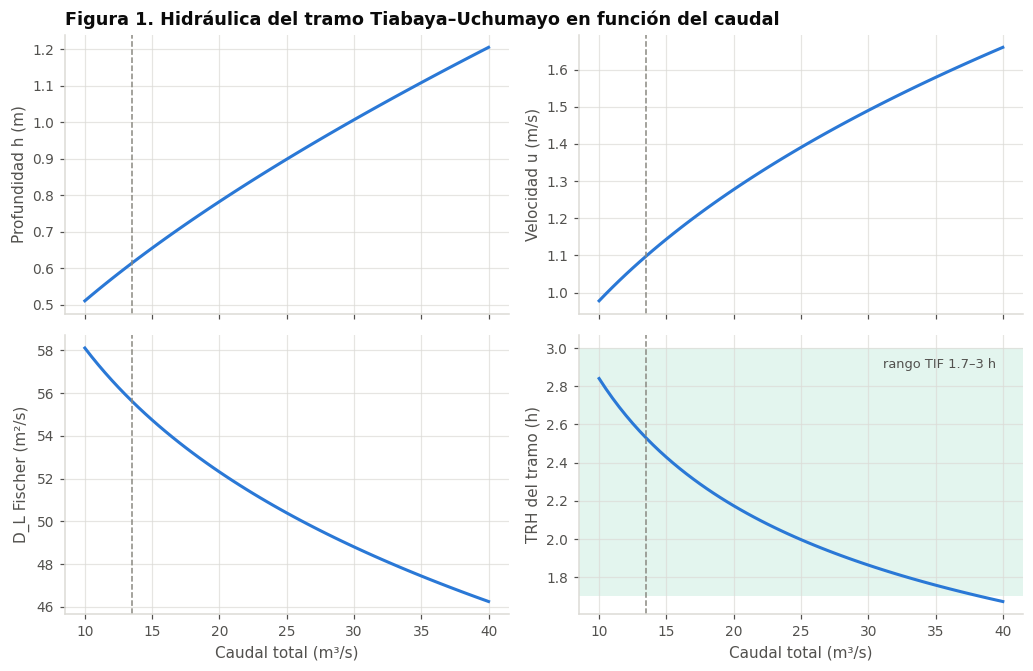

In [5]:
Qs = np.linspace(10, 40, 61)
H  = pd.DataFrame([hidraulica(q) for q in Qs])
fig, ax = plt.subplots(2, 2, figsize=(9.5, 6.2), sharex=True)
for a, (col, lab) in zip(ax.flat, [("h", "Profundidad h (m)"), ("u", "Velocidad u (m/s)"),
                                    ("DL", "D_L Fischer (m²/s)"), ("TRH_h", "TRH del tramo (h)")]):
    a.plot(H["Q"], H[col], color=COL["s1"])
    a.axvline(Q_RIO + Q_EF, color=COL["muted"], lw=1, ls="--")
    a.set_ylabel(lab)
ax[1, 0].set_xlabel("Caudal total (m³/s)"); ax[1, 1].set_xlabel("Caudal total (m³/s)")
ax[1, 1].axhspan(1.7, 3.0, color=COL["s3"], alpha=0.12, lw=0)
ax[1, 1].text(39.5, 2.95, "rango TIF 1.7–3 h", ha="right", va="top", fontsize=8.5, color=COL["ink2"])
ax[0, 0].set_title("Figura 1. Hidráulica del tramo Tiabaya–Uchumayo en función del caudal")
fig.tight_layout(); guardar(fig, "fig01_hidraulica"); plt.show()

---
# 3. Destino: degradación, partición, volatilización y bioconcentración (sección 2.3)

$$k = k_{bio}+k_{foto}+k_{hid}+k_{vol}+k_{sed},\qquad k_i=\frac{\ln 2}{t_{1/2}}$$

$$K_d=K_{oc}f_{oc},\qquad f_d=\frac{1}{1+K_d\,SS\,10^{-6}},\qquad k_{sed}=\frac{(1-f_d)\,v_s}{h}$$

**Volatilización** (dos películas): $H'=K_H/(RT)$, $\;1/K_L = 1/k_l + 1/(H' k_g)$, $\;k_{vol}=K_L/h$,
con $k_l=\sqrt{D_w u/h}$ (O'Connor–Dobbins) y $k_g$ de la correlación de Schwarzenbach
($v_a \approx 0.2\,U_{10}+0.3$ cm/s, corregida por peso molecular).

**Dependencias con el ambiente** usadas en el modelo de procesos: $k_{bio}(T)=k_{bio,20}\,\theta^{T-20}$ y
$k_{foto}(t)=\bar k_{foto}\,I_0(t)/\bar I_0$ (proporcional a la radiación instantánea).

**Bioconcentración:** $BCF=C_{org}/C_{agua}=k_1/k_2$.

In [6]:
# ============================================================================
# 3. CONSTANTES DE DESTINO
# ============================================================================
def henry_adim(T_C):
    return KH / (R * (T_C + 273.15))

def k_volatilizacion(T_C, u, h, U10=U_VIENTO):
    """k_vol = K_L/h [1/d] por teoría de dos películas."""
    kl = np.sqrt(D_AGUA * u / h) * DAY                              # m/d
    kg = (0.2*U10 + 0.3) / 100 * DAY * (18.0/MW_PAP)**(1/3)          # m/d
    KL = 1.0 / (1.0/kl + 1.0/(henry_adim(T_C)*kg))
    return KL / h, KL, kl, kg

def fraccion_disuelta(SS, foc=FOC_SS):
    Kd = KOC * foc                                                   # L/kg
    return 1.0 / (1.0 + Kd * SS * 1e-6), Kd

def k_sedimentacion(SS, h, foc=FOC_SS, vs=V_SED):
    fd, _ = fraccion_disuelta(SS, foc)
    return (1.0 - fd) * vs / h

def constantes_k(T_C=15.0, I_rel=1.0, SS=25.0, u=None, h=None,
                 t12_bio=T12_BIO, t12_foto=T12_FOTO, t12_hid=T12_HID, theta=THETA):
    """Devuelve las constantes de primer orden [1/d] para condiciones dadas."""
    u = HB["u"] if u is None else u
    h = HB["h"] if h is None else h
    kbio  = LN2/t12_bio * theta**(T_C - 20)
    kfoto = LN2/t12_foto * I_rel
    khid  = LN2/t12_hid
    kvol  = k_volatilizacion(T_C, u, h)[0]
    ksed  = k_sedimentacion(SS, h)
    return dict(k_bio=kbio, k_foto=kfoto, k_hid=khid, k_vol=kvol, k_sed=ksed,
                k_total=kbio + kfoto + khid + kvol + ksed)

KB = constantes_k(T_C=15.0, I_rel=1.0, SS=25.0)
df_k = pd.DataFrame({"Proceso": list(KB.keys()),
                     "k (1/d)": list(KB.values()),
                     "t½ (d)": [LN2/v if v > 0 else np.inf for v in KB.values()]})
df_k["Pérdida en el tramo (%)"] = 100*(1 - np.exp(-df_k["k (1/d)"]*HB["TRH_d"]))
tabla(df_k, "t04_constantes_destino", "Tabla 4. Constantes de pérdida de primer orden (15 °C, SS = 25 mg/L)", precision=6)
anotar("k_total", KB["k_total"], "1/d", "k total nominal (15 °C)")

fd, Kd = fraccion_disuelta(25.0)
vk, KL, kl, kg = k_volatilizacion(15.0, HB["u"], HB["h"])
df_part = pd.DataFrame([{
    "Kd (L/kg)": Kd, "f_d (SS=25)": fd, "f_d (SS=400)": fraccion_disuelta(400.0)[0],
    "H' (-)": henry_adim(15.0), "k_l (m/d)": kl, "k_g (m/d)": kg, "K_L (m/d)": KL, "k_vol (1/d)": vk,
}])
tabla(df_part, "t05_particion_volatilizacion", "Tabla 5. Partición agua–sólidos y volatilización", precision=8)

df_bcf = pd.DataFrame([{"Especie": e, "BCF (L/kg)": p["BCF"], "k2 (1/d)": p["k2"],
                        "k1 = BCF·k2 (L/kg/d)": p["BCF"]*p["k2"], "t95 equilibrio (d)": 3/p["k2"]}
                       for e, p in ESPECIES.items()])
tabla(df_bcf, "t06_bioconcentracion", "Tabla 6. Cinética de captación (k2 supuestos; BCF en rango 10–46)")

**Tabla 4. Constantes de pérdida de primer orden (15 °C, SS = 25 mg/L)**  ·  `tif_pap/resultados/t04_constantes_destino.csv`

Proceso,k (1/d),t½ (d),Pérdida en el tramo (%)
k_bio,0.009182,75.489171,0.096711
k_foto,0.069315,10.000000,0.727753
k_hid,0.001899,365.000000,0.020009
k_vol,0.000005,153072.842540,0.000048
k_sed,0.000074,9341.922140,0.000782
k_total,0.080475,8.613247,0.844427


**Tabla 5. Partición agua–sólidos y volatilización**  ·  `tif_pap/resultados/t05_particion_volatilizacion.csv`

Kd (L/kg),f_d (SS=25),f_d (SS=400),H' (-),k_l (m/d),k_g (m/d),K_L (m/d),k_vol (1/d)
1.82402168,0.99995440,0.99927092,0.00000001,3.46518081,331.68148751,0.00000278,0.00000453


**Tabla 6. Cinética de captación (k2 supuestos; BCF en rango 10–46)**  ·  `tif_pap/resultados/t06_bioconcentracion.csv`

Especie,BCF (L/kg),k2 (1/d),k1 = BCF·k2 (L/kg/d),t95 equilibrio (d)
Alga (P. subcapitata),46,2.00000,92.00000,1.50000
Daphnia magna,25,1.00000,25.00000,3.00000
Trucha (O. mykiss),10,0.30000,3.00000,10.00000


,Especie,BCF (L/kg),k2 (1/d),k1 = BCF·k2 (L/kg/d),t95 equilibrio (d)
0,Alga (P. subcapitata),46,2.0,92.0,1.5
1,Daphnia magna,25,1.0,25.0,3.0
2,Trucha (O. mykiss),10,0.3,3.0,10.0


### 3.1 Fugacidad nivel III (verificación de la distribución entre compartimentos)

Se usa un ambiente evaluativo tipo EQC/Mackay (aire–agua–sedimento) con emisión **solo al agua**.
En estado estacionario:

$$E_w + f_a D_{aw} + f_s D_{sw} = f_w\,(D_{A,w}+D_{R,w}+D_{wa}+D_{ws})$$
$$f_w D_{wa} = f_a\,(D_{aw}+D_{A,a}+D_{R,a}),\qquad f_w D_{ws} = f_s\,(D_{sw}+D_{R,s}+D_{B,s})$$

con $Z_{aire}=1/RT$, $Z_{agua}=1/K_H$, $Z_{sed}=K_d\,\rho_{sed}/K_H$ y masas $m_i=V_iZ_if_i$.
Los volúmenes y velocidades de transferencia son valores típicos de un mundo evaluativo (supuestos).

In [7]:
# ============================================================================
# 3.1 FUGACIDAD NIVEL III (aire – agua – sedimento), unidades horarias
# ============================================================================
def fugacidad_nivel3(T_C=15.0, t12_aire_h=5.0, t12_agua_h=15*24, t12_sed_h=60*24):
    T = T_C + 273.15
    Za = 1/(R*T); Zw = 1/KH
    Zp  = KOC*0.20*2.4*Zw                 # partículas suspendidas (foc 0.20, ρ 2.4 kg/L)
    Zss = KOC*0.04*2.4*Zw                 # sólidos del sedimento (foc 0.04)
    Zw_b = Zw + 5e-6*Zp                    # agua con partículas
    Zs_b = 0.8*Zw + 0.2*Zss                # sedimento: 80 % agua de poro, 20 % sólidos
    Aw = 1e10; Vw = 2e11; Va = 1e14; Vs = Aw*0.01   # m², m³
    # D (mol/(Pa·h))
    D_vol = 1/(1/(0.05*Aw*Zw) + 1/(5.0*Aw*Za))
    D_llu = 9.7e-5*Aw*Zw
    D_aw  = D_vol + D_llu;  D_wa = D_vol
    D_dif = 1e-4*Aw*Zw
    D_ws  = D_dif + 5000*Zp
    D_sw  = D_dif + 2000*Zss
    D_Bs  = 3000*Zss
    D_Aw  = Vw/1000*Zw_b;   D_Aa = Va/100*Za
    D_Rw  = LN2/t12_agua_h*Vw*Zw_b
    D_Ra  = LN2/t12_aire_h*Va*Za
    D_Rs  = LN2/t12_sed_h*Vs*Zs_b
    E = 1.0  # mol/h emitido al agua
    M = np.array([[D_Aw + D_Rw + D_wa + D_ws, -D_aw, -D_sw],
                  [-D_wa, D_aw + D_Aa + D_Ra, 0.0],
                  [-D_ws, 0.0, D_sw + D_Rs + D_Bs]])
    fw, fa, fs = np.linalg.solve(M, [E, 0.0, 0.0])
    masas = {"Agua": Vw*Zw_b*fw, "Aire": Va*Za*fa, "Sedimento": Vs*Zs_b*fs}
    tot = sum(masas.values())
    salidas = {"Advección agua": D_Aw*fw, "Degradación agua": D_Rw*fw,
               "Degradación sedimento": D_Rs*fs, "Enterramiento": D_Bs*fs,
               "Advección + reacción aire": (D_Aa + D_Ra)*fa}
    return ({k: 100*v/tot for k, v in masas.items()},
            {k: 100*v/E for k, v in salidas.items()})

dist, fates = fugacidad_nivel3()
df_fug = pd.DataFrame({"Compartimento": dist.keys(), "Masa (%)": dist.values()})
tabla(df_fug, "t07_fugacidad_distribucion", "Tabla 7. Distribución por fugacidad nivel III (doc.: 99.5 % en agua)", precision=4)
df_fates = pd.DataFrame({"Vía de salida": fates.keys(), "% de la emisión": fates.values()})
tabla(df_fates, "t08_fugacidad_salidas", "Tabla 8. Destino de la emisión (nivel III)", precision=3)
anotar("fug_agua", dist["Agua"], "%", "Fracción del PAP en agua (nivel III)")

**Tabla 7. Distribución por fugacidad nivel III (doc.: 99.5 % en agua)**  ·  `tif_pap/resultados/t07_fugacidad_distribucion.csv`

Compartimento,Masa (%)
Agua,99.8669
Aire,0.0000
Sedimento,0.1331


**Tabla 8. Destino de la emisión (nivel III)**  ·  `tif_pap/resultados/t08_fugacidad_salidas.csv`

Vía de salida,% de la emisión
Advección agua,34.174
Degradación agua,65.799
Degradación sedimento,0.022
Enterramiento,0.005
Advección + reacción aire,0.000


99.86693366731834

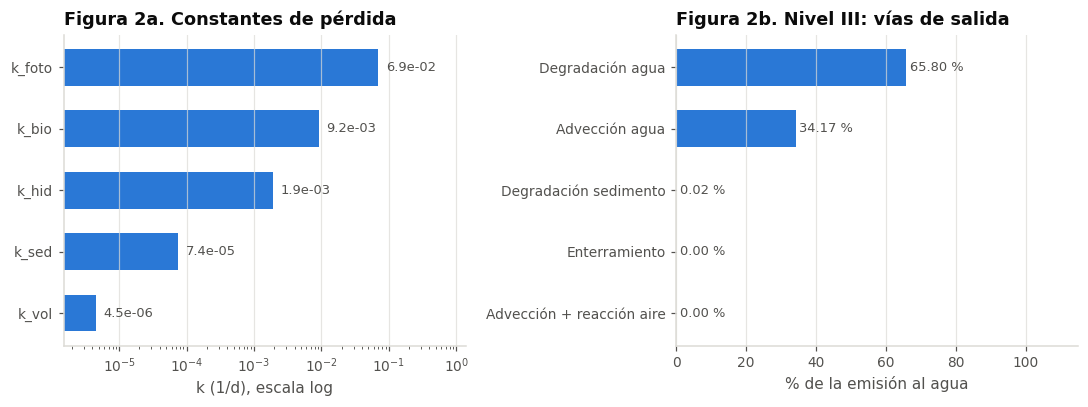

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(10, 3.8))
kk = df_k[df_k["Proceso"] != "k_total"].sort_values("k (1/d)")
ax[0].barh(kk["Proceso"], kk["k (1/d)"], color=COL["s1"], height=0.6)
ax[0].set_xscale("log"); ax[0].set_xlabel("k (1/d), escala log")
ax[0].set_title("Figura 2a. Constantes de pérdida")
for y, v in enumerate(kk["k (1/d)"]):
    ax[0].text(v*1.3, y, f"{v:.1e}", va="center", fontsize=8.5, color=COL["ink2"])
ax[0].set_xlim(kk["k (1/d)"].min()/3, kk["k (1/d)"].max()*20)
ax[0].grid(axis="y", visible=False)

ff = df_fates.sort_values("% de la emisión")
ax[1].barh(ff["Vía de salida"], ff["% de la emisión"], color=COL["s1"], height=0.6)
ax[1].set_xlabel("% de la emisión al agua"); ax[1].set_title("Figura 2b. Nivel III: vías de salida")
for y, v in enumerate(ff["% de la emisión"]):
    ax[1].text(v + 1, y, f"{v:.2f} %", va="center", fontsize=8.5, color=COL["ink2"])
ax[1].set_xlim(0, 115); ax[1].grid(axis="y", visible=False)
fig.tight_layout(); guardar(fig, "fig02_destino_fugacidad"); plt.show()

---
# 4. Efectos: dosis–respuesta, CL50 y riesgo (sección 2.4)

**Log-logístico de dos parámetros:** $M(C)=\dfrac{1}{1+(CL_{50}/C)^b}$

**Probit:** $\text{Probit}(M)=a+b_p\log_{10}C$, con Probit = 5 en la CL50 y $M=\Phi(\text{Probit}-5)$.

**Riesgo:** $UT=C_{amb}/CL_{50}$, $\;HQ=C_{amb}/PNEC$, $\;PNEC=NOEC_{mín}/FA=0.036/10$.

Como el documento no reporta pendientes, $b$ se estima suponiendo que el NOEC corresponde
aproximadamente a la CE10: $b=\ln 9/\ln(CL_{50}/NOEC)$, acotado al intervalo típico de ensayos agudos
$2\le b\le 6$. La cota es necesaria porque para la trucha el NOEC es crónico y la CL50 aguda: sin ella
saldría $b\approx0.75$, una curva tan plana que predeciría mortalidad a concentraciones mil veces
menores que la CL50. La pendiente probit equivalente (misma
desviación estándar en log C) es $b_p = b\,\sqrt3\,\ln 10/\pi$.

Para acoplar con la biota, la fracción afectada durante la duración del ensayo se convierte en tasa:
$m_{tox}=-\ln(1-M)/T_{ensayo}$.

In [9]:
# ============================================================================
# 4. DOSIS–RESPUESTA Y RIESGO
# ============================================================================
for e, p in ESPECIES.items():
    p["b_NOEC"] = np.log(9.0) / np.log(p["CL50"]/p["NOEC"])
    p["b"]  = float(np.clip(p["b_NOEC"], 2.0, 6.0))
    p["bp"] = p["b"] * np.sqrt(3) * np.log(10) / np.pi
    p["a"]  = 5.0 - p["bp"]*np.log10(p["CL50"])

def mortalidad_loglogistica(C, CL50, b):
    C = np.maximum(np.asarray(C, dtype=float), 1e-15)
    return 1.0 / (1.0 + (CL50/C)**b)

def mortalidad_probit(C, a, bp):
    C = np.maximum(np.asarray(C, dtype=float), 1e-15)
    return norm.cdf(a + bp*np.log10(C) - 5.0)

def m_tox(C_eq, p):
    """Tasa de mortalidad adicional [1/d] a partir de la concentración equivalente externa."""
    M = np.clip(mortalidad_loglogistica(C_eq, p["CL50"], p["b"]), 0, 0.999)
    return -np.log(1 - M) / p["T_ens"]

df_dr = pd.DataFrame([{"Especie": e, "CL50/CE50 (mg/L)": p["CL50"], "NOEC (mg/L)": p["NOEC"],
                       "b desde NOEC": p["b_NOEC"], "b usado": p["b"], "a probit": p["a"], "b probit": p["bp"],
                       "Ensayo (d)": p["T_ens"]} for e, p in ESPECIES.items()])
tabla(df_dr, "t09_dosis_respuesta", "Tabla 9. Parámetros dosis–respuesta por especie", precision=4)
anotar("PNEC", PNEC, "mg/L", "PNEC = 0.036/10")

**Tabla 9. Parámetros dosis–respuesta por especie**  ·  `tif_pap/resultados/t09_dosis_respuesta.csv`

Especie,CL50/CE50 (mg/L),NOEC (mg/L),b desde NOEC,b usado,a probit,b probit,Ensayo (d)
Alga (P. subcapitata),0.1500,0.0360,1.5396,2.0000,7.0919,2.5390,3.0000
Daphnia magna,0.0980,0.0550,3.8038,3.8038,9.8713,4.8289,2.0000
Trucha (O. mykiss),1.2000,0.0640,0.7496,2.0000,4.7990,2.5390,4.0000


0.0036

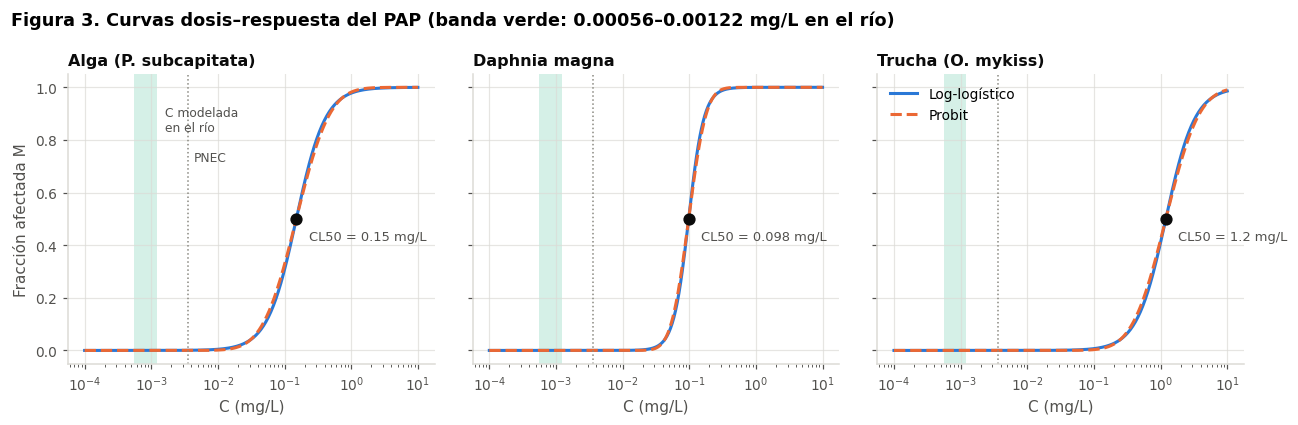

In [10]:
C_rng = (mezcla(C_EF_MIN), mezcla(C_EF_MAX))
Cc = np.logspace(-4, 1, 400)
fig, ax = plt.subplots(1, 3, figsize=(12, 3.9), sharey=True)
for a_, (e, p) in zip(ax, ESPECIES.items()):
    a_.axvspan(*C_rng, color=COL["s3"], alpha=0.18, lw=0)
    a_.plot(Cc, mortalidad_loglogistica(Cc, p["CL50"], p["b"]), color=COL["s1"], label="Log-logístico")
    a_.plot(Cc, mortalidad_probit(Cc, p["a"], p["bp"]), color=COL["s2"], ls="--", label="Probit")
    a_.plot([p["CL50"]], [0.5], "o", color=COL["ink"], ms=7, zorder=5)
    a_.annotate(f"CL50 = {p['CL50']} mg/L", (p["CL50"], 0.5), xytext=(8, -14),
                textcoords="offset points", fontsize=8.5, color=COL["ink2"])
    a_.axvline(PNEC, color=COL["muted"], lw=1, ls=":")
    a_.set_xscale("log"); a_.set_title(e, fontsize=10.5); a_.set_xlabel("C (mg/L)")
ax[0].set_ylabel("Fracción afectada M")
ax[0].text(C_rng[1]*1.3, 0.93, "C modelada\nen el río", fontsize=8, color=COL["ink2"], va="top")
ax[0].text(PNEC*1.2, 0.72, "PNEC", fontsize=8, color=COL["ink2"])
ax[2].legend(loc="upper left")
fig.suptitle("Figura 3. Curvas dosis–respuesta del PAP (banda verde: 0.00056–0.00122 mg/L en el río)",
             x=0.01, ha="left", fontweight="bold", fontsize=11.5)
fig.tight_layout(); guardar(fig, "fig03_dosis_respuesta"); plt.show()

**Sensibilidad por estadio de vida.** Zhang et al. (2026) muestran que los embriones son el estadio más
sensible. Sin CL50 por estadio para las especies del tramo, se aplica un factor ilustrativo
(**supuesto**) a la CL50 de la trucha: embrión ×0.1, juvenil ×0.4, adulto ×1.

In [11]:
C_max_rio = mezcla(C_EF_MAX)
pt = ESPECIES["Trucha (O. mykiss)"]
df_est = pd.DataFrame([{"Estadio (trucha)": est, "Factor CL50": f, "CL50 (mg/L)": pt["CL50"]*f,
                        "UT con C máx.": C_max_rio/(pt["CL50"]*f),
                        "M con C máx.": float(mortalidad_loglogistica(C_max_rio, pt["CL50"]*f, pt["b"]))}
                       for est, f in [("Embrión", 0.1), ("Juvenil", 0.4), ("Adulto", 1.0)]])
tabla(df_est, "t10_estadios", "Tabla 10. Unidades tóxicas por estadio (ilustrativo)", precision=5)

**Tabla 10. Unidades tóxicas por estadio (ilustrativo)**  ·  `tif_pap/resultados/t10_estadios.csv`

Estadio (trucha),Factor CL50,CL50 (mg/L),UT con C máx.,M con C máx.
Embrión,0.10000,0.12000,0.01019,0.00010
Juvenil,0.40000,0.48000,0.00255,0.00001
Adulto,1.00000,1.20000,0.00102,0.00000


,Estadio (trucha),Factor CL50,CL50 (mg/L),UT con C máx.,M con C máx.
0,Embrión,0.1,0.12,0.010185,0.000104
1,Juvenil,0.4,0.48,0.002546,0.000006
2,Adulto,1.0,1.20,0.001019,0.000001


---
# 5. Modelo empírico (sección 4)

Modelo de **dilución con decaimiento de primer orden** a lo largo del tramo:

$$C(x)=\frac{W}{Q_{ef}+Q_{río}}\;e^{-k\,x/u}$$

Se reproducen los cálculos de verificación del documento: $C_0\approx 0.00086$ mg/L, $e^{-0.1\times0.1}=0.99$,
$UT_{Daphnia}=0.0088$, $UT_{alga}=0.0057$, $HQ\approx0.24$ y $HQ_{máx}\approx0.34$.
La regresión potencial $C_{río}=a\,W^bQ_{río}^c$ se ajusta en la sección 7 con los datos Monte Carlo.

In [12]:
# ============================================================================
# 5. MODELO EMPÍRICO
# ============================================================================
def C_empirico(x, W, Q_rio=Q_RIO, Q_ef=Q_EF, k=0.1, u=None):
    """C(x) = W/(Qef+Qrío) · exp(-k x/u)  [mg/L];  W g/d, Q m³/s, x m, k 1/d, u m/s."""
    u = HB["u"] if u is None else u
    return W / ((Q_ef + Q_rio)*DAY) * np.exp(-k * (np.asarray(x)/u) / DAY)

C0_emp = C_empirico(0, W_BASE)
fac_doc = np.exp(-0.1*0.1)                                   # TRH 0.1 d, k 0.1 1/d
fac_mod = np.exp(-0.1*HB["TRH_d"])
UT_d = C0_emp / ESPECIES["Daphnia magna"]["CL50"]
UT_a = C0_emp / ESPECIES["Alga (P. subcapitata)"]["CL50"]
HQ0  = C0_emp / PNEC
HQmx = mezcla(C_EF_MAX) / PNEC

ver = pd.DataFrame([
    ("C0 con W = 1000 g/d (mg/L)", 0.00086, C0_emp),
    ("Factor de pérdida e^(-k·TRH), TRH = 0.1 d", 0.99, fac_doc),
    ("Factor de pérdida con TRH del modelo", 0.99, fac_mod),
    ("C0 con W = 648 g/d (mg/L)", 0.00056, C_empirico(0, carga(C_EF_MIN))),
    ("C0 con W = 1426 g/d (mg/L)", 0.00122, C_empirico(0, carga(C_EF_MAX))),
    ("UT Daphnia", 0.0088, UT_d),
    ("UT alga", 0.0057, UT_a),
    ("PNEC (mg/L)", 0.0036, PNEC),
    ("HQ (W = 1000 g/d)", 0.24, HQ0),
    ("HQ máximo (W = 1426 g/d)", 0.34, HQmx),
], columns=["Magnitud", "Documento", "Calculado"])
ver["Dif. relativa (%)"] = 100*(ver["Calculado"] - ver["Documento"])/ver["Documento"]
ver["Verificación"] = np.where(ver["Dif. relativa (%)"].abs() < 3, "✔", "revisar")
tabla(ver, "t11_verificacion_empirico", "Tabla 11. Verificación del modelo empírico frente al documento", precision=5)

anotar("C0_emp", C0_emp, "mg/L", "C0 empírico (W=1000 g/d)")
anotar("HQ_emp", HQ0, "-", "HQ empírico (W=1000 g/d)")
anotar("HQ_emp_max", HQmx, "-", "HQ empírico máximo (W=1426 g/d)")

**Tabla 11. Verificación del modelo empírico frente al documento**  ·  `tif_pap/resultados/t11_verificacion_empirico.csv`

Magnitud,Documento,Calculado,Dif. relativa (%),Verificación
C0 con W = 1000 g/d (mg/L),0.00086,0.00086,-0.30944,✔
"Factor de pérdida e^(-k·TRH), TRH = 0.1 d",0.99000,0.99005,0.00503,✔
Factor de pérdida con TRH del modelo,0.99000,0.98952,-0.04872,✔
C0 con W = 648 g/d (mg/L),0.00056,0.00056,-0.79365,✔
C0 con W = 1426 g/d (mg/L),0.00122,0.00122,0.18215,✔
UT Daphnia,0.00880,0.00875,-0.58687,✔
UT alga,0.00570,0.00572,0.27355,✔
PNEC (mg/L),0.00360,0.00360,0.00000,✔
HQ (W = 1000 g/d),0.24000,0.23815,-0.77097,✔
HQ máximo (W = 1426 g/d),0.34000,0.33951,-0.14524,✔


0.3395061728395062

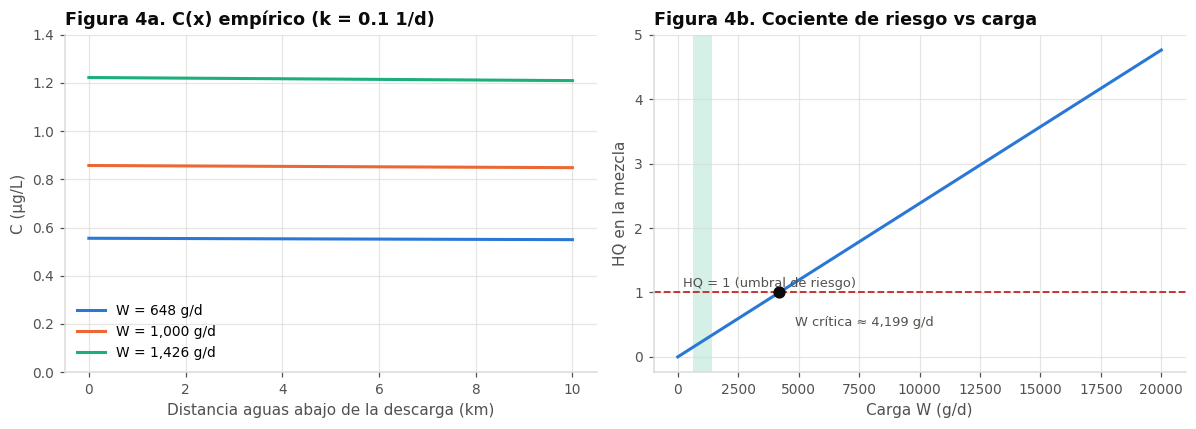

Carga crítica (HQ = 1) en estiaje: 4,199 g/d  ->  4.2 veces la carga del escenario


In [13]:
x = np.linspace(0, L_TRAMO, 201)
Ws = [carga(C_EF_MIN), W_BASE, carga(C_EF_MAX)]
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
for i, W in enumerate(Ws):
    ax[0].plot(x/1000, C_empirico(x, W)*1000, color=SERIES[i], label=f"W = {W:,.0f} g/d")
ax[0].set_xlabel("Distancia aguas abajo de la descarga (km)"); ax[0].set_ylabel("C (µg/L)")
ax[0].set_ylim(0, 1.4); ax[0].legend(loc="lower left")
ax[0].set_title("Figura 4a. C(x) empírico (k = 0.1 1/d)")

Wg = np.linspace(0, 20000, 300)
ax[1].plot(Wg, C_empirico(0, Wg)/PNEC, color=COL["s1"])
ax[1].axhline(1, color=COL["crit"], lw=1.2, ls="--")
ax[1].text(200, 1.08, "HQ = 1 (umbral de riesgo)", fontsize=8.5, color=COL["ink2"])
ax[1].axvspan(Ws[0], Ws[2], color=COL["s3"], alpha=0.18, lw=0)
W_crit = PNEC * (Q_EF + Q_RIO) * DAY
ax[1].plot([W_crit], [1], "o", color=COL["ink"], ms=7)
ax[1].annotate(f"W crítica ≈ {W_crit:,.0f} g/d", (W_crit, 1), xytext=(10, -22),
               textcoords="offset points", fontsize=8.5, color=COL["ink2"])
ax[1].set_xlabel("Carga W (g/d)"); ax[1].set_ylabel("HQ en la mezcla")
ax[1].set_title("Figura 4b. Cociente de riesgo vs carga")
fig.tight_layout(); guardar(fig, "fig04_modelo_empirico"); plt.show()
anotar("W_critica", W_crit, "g/d", "Carga que produce HQ = 1 en estiaje")
print(f"Carga crítica (HQ = 1) en estiaje: {W_crit:,.0f} g/d  ->  {W_crit/W_BASE:.1f} veces la carga del escenario")

---
# 6. Modelo basado en procesos (sección 5, tipo AQUATOX)

## 6.1 Estructura

**Tóxico en la columna de agua**, discretizado en $N=100$ segmentos de $\Delta x=100$ m (método de las
líneas, tanques en serie con dispersión):

$$V\frac{dC_i}{dt}=W_i+Q\,C_{i-1}-Q\,C_i+E\,(C_{i-1}-2C_i+C_{i+1})-V(k_{bio}+k_{foto}+k_{hid})C_i-K_LA_sC_i-k_{sor}C_i+k_{des}M_i$$

$$\frac{dM_i}{dt}=k_{sor}C_i-(k_{des}+k_{deg,s})M_i,\qquad k_{sor}=k_{sed}V$$

donde $W$ entra al primer segmento, $E=\max(D_L-u\Delta x/2,\,0)\,A/\Delta x$ y $M_i$ es la masa de PAP en
el sedimento del segmento. $K_LA_s = k_{vol}V$ (se usa la forma dimensionalmente consistente).

**Biota** (promedio del tramo), con la estructura del documento $dB/dt=(\mu-r-m-m_{tox}-p-w)B$:

* Fitoplancton: $\mu=\mu_{máx}\,f(luz)\,f(T)\,f(N)$; $f(luz)$ de Steele integrado en la profundidad con
  Lambert–Beer $I(z)=I_0e^{-k_{ext}z}$; $f(T)=e^{-2.3|T-T_{ópt}|/(T_{ópt}-T_{mín})}$; $f(N)=N/(K_N+N)$.
* Daphnia: $\mu = \varepsilon\,g_{máx}f(T)\,B_p/(K_g+B_p)$; su pastoreo es la depredación $p$ del fitoplancton.
* Trucha: consume Daphnia y alimento alternativo (bentos), con mortalidad dependiente de la densidad.
* **Washout** $w=Q/V$ para plancton, con reposición desde aguas arriba $w\,B_{up}$ (en un tramo de 2.5 h
  de TRH la biomasa planctónica local está controlada por la que llega de aguas arriba).
* Mortalidad tóxica: $m_{tox}=-\ln(1-M(C_{org}/BCF))/T_{ensayo}$ con $dC_{org}/dt=k_1C_{agua}-k_2C_{org}$.

**Acoplamiento.** La masa de PAP captada por la biota es despreciable frente a la del agua (BCF ≤ 46 y
biomasas < 1 mg/L), por lo que el acople es en un solo sentido: primero se resuelve el tóxico y
luego la biota con la concentración resultante.

**Solución numérica.** `solve_ivp` (BDF con jacobiano disperso, adecuado para el sistema rígido de
advección) con salida **horaria durante 365 días**.

## 6.2 Forzantes horarios del año

No hay series medidas en el tramo, por lo que se construyen forzantes sintéticos coherentes con el
escenario: estiaje con $Q_{río}=12$ m³/s y época de lluvias (enero–marzo) con aumento de caudal y
sólidos; T 12–18 °C; pH 7.0–8.3; radiación con ciclo diario; carga y caudal del efluente con ciclo
diario de la PTAR (media $W$); OD saturado corregido por altitud (2335 msnm).

In [14]:
# ============================================================================
# 6.2 FORZANTES
# ============================================================================
P_ATM_REL = (1 - 2.25577e-5*ALTITUD)**5.25588        # presión relativa a 2335 msnm

def OD_sat(T_C):
    """OD de saturación (mg/L) a nivel del mar corregido por altitud."""
    od0 = 14.652 - 0.41022*T_C + 0.007991*T_C**2 - 0.000077774*T_C**3
    return od0 * P_ATM_REL

def forzantes(t, W_media=W_BASE):
    """Forzantes en el tiempo t (d desde el 1 de enero). Acepta escalares o arreglos."""
    t = np.asarray(t, dtype=float)
    doy = t % 365.0; hr = (t % 1.0)*24.0
    lluvia = np.exp(-((doy - 45.0)/28.0)**2)                       # pico a mediados de febrero
    Q_rio = Q_RIO + 22.0*lluvia                                    # m³/s
    ciclo = np.sin(2*np.pi*(hr - 8.0)/24.0)                        # máximo a las 14 h
    Q_ef  = Q_EF*(1 + 0.2*ciclo)
    W     = W_media*(1 + 0.3*ciclo)                                # g/d (media = W_media)
    T     = 15.0 + 2.0*np.cos(2*np.pi*(doy - 30)/365) + 1.0*np.sin(2*np.pi*(hr - 9)/24)
    Imax  = (430.0 + 40.0*np.cos(2*np.pi*(doy - 355)/365))*(1 - 0.4*lluvia)
    I0    = Imax*np.maximum(0.0, np.sin(np.pi*(hr - 6.0)/12.0))    # W/m² PAR
    pH    = 7.65 + 0.3*np.sin(2*np.pi*(hr - 10)/24) + 0.3*np.cos(2*np.pi*(doy - 230)/365)
    OD    = OD_sat(T)*(0.92 + 0.06*np.sin(2*np.pi*(hr - 10)/24))
    SS    = 25.0 + 400.0*lluvia                                    # mg/L
    N     = 0.35 + 0.10*np.cos(2*np.pi*(doy - 200)/365)            # mg/L N inorgánico
    return dict(Q_rio=Q_rio, Q_ef=Q_ef, W=W, T=T, I0=I0, pH=pH, OD=OD, SS=SS, N=N)

T_HORAS = np.arange(0, 365*24 + 1)/24.0                            # 8761 instantes horarios
FZ = pd.DataFrame(forzantes(T_HORAS)); FZ.insert(0, "t_d", T_HORAS)
I_MEDIA = FZ["I0"].mean()                                          # radiación media anual (24 h)

res = FZ.drop(columns="t_d").describe().T[["mean", "min", "max"]]
res.insert(0, "Variable", res.index)
tabla(res.reset_index(drop=True), "t12_forzantes_resumen", "Tabla 12. Resumen de forzantes horarios (365 d)", precision=3)

**Tabla 12. Resumen de forzantes horarios (365 d)**  ·  `tif_pap/resultados/t12_forzantes_resumen.csv`

Variable,mean,min,max
Q_rio,14.957,12.000,34.000
Q_ef,1.500,1.200,1.800
W,999.970,700.000,1300.000
T,15.000,12.000,18.000
I0,128.388,0.000,469.999
pH,7.650,7.050,8.250
OD,6.949,6.347,7.574
SS,78.760,25.000,425.000
N,0.350,0.250,0.450


,Variable,mean,min,max
0,Q_rio,14.956813,12.000000,34.000000
1,Q_ef,1.499970,1.200000,1.800000
2,W,999.970345,700.000000,1300.000000
3,T,15.000118,12.000042,17.999958
4,I0,128.387764,0.000000,469.998518
5,pH,7.649959,7.050005,8.249995
6,OD,6.949232,6.347187,7.574371
7,SS,78.760235,25.000000,425.000000
8,N,0.349989,0.250000,0.450000


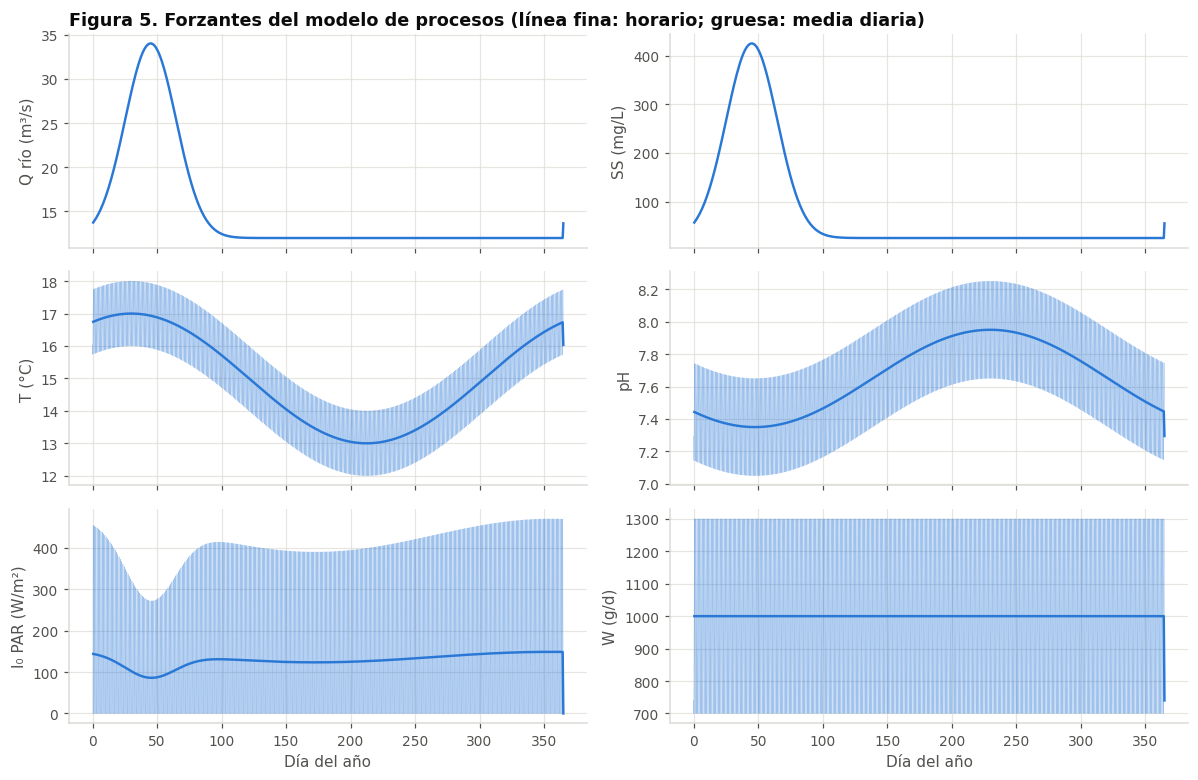

In [15]:
fig, ax = plt.subplots(3, 2, figsize=(11, 7.2), sharex=True)
panels = [("Q_rio", "Q río (m³/s)"), ("SS", "SS (mg/L)"), ("T", "T (°C)"),
          ("pH", "pH"), ("I0", "I₀ PAR (W/m²)"), ("W", "W (g/d)")]
daily = FZ.groupby((FZ["t_d"]//1).astype(int)).mean()
for a_, (c, lab) in zip(ax.flat, panels):
    a_.plot(FZ["t_d"], FZ[c], color=COL["s1"], lw=0.35, alpha=0.45)
    a_.plot(daily["t_d"], daily[c], color=COL["s1"], lw=1.6)
    a_.set_ylabel(lab)
ax[2, 0].set_xlabel("Día del año"); ax[2, 1].set_xlabel("Día del año")
ax[0, 0].set_title("Figura 5. Forzantes del modelo de procesos (línea fina: horario; gruesa: media diaria)")
fig.tight_layout(); guardar(fig, "fig05_forzantes"); plt.show()

## 6.3 Tóxico en agua y sedimento

In [16]:
# ============================================================================
# 6.3 MODELO DE PROCESOS — PAP EN AGUA Y SEDIMENTO
# ============================================================================
PARAM_NOMINAL = dict(t12_bio=T12_BIO, t12_foto=T12_FOTO, t12_hid=T12_HID, theta=THETA,
                     foc=FOC_SS, vs=V_SED, k_res=K_RES, t12_sed=T12_SED,
                     # procesos que NO incluye el modelo nominal (se usan en la sección 7)
                     foto_pantalla=False, kfoto_max=0.0, kox8=0.0, od_monod=False, M_up=0.0)

def k_agua(T, I0, SS, pH, OD, h, u, p):
    """Constantes de pérdida en agua [1/d] para las condiciones dadas y el juego de parámetros p."""
    kbio = LN2/p["t12_bio"] * p["theta"]**(T - 20)
    if p["od_monod"]:
        kbio = kbio * (OD/(1.5 + OD)) / (8.0/(1.5 + 8.0))
    if p["foto_pantalla"]:                                   # atenuación por turbidez y profundidad
        kext = 0.5 + 0.06*SS
        pant = (1 - np.exp(-kext*h))/(kext*h)
        kfoto = p["kfoto_max"] * (I0/450.0) * pant
    else:
        kfoto = LN2/p["t12_foto"] * I0/I_MEDIA
    khid = LN2/p["t12_hid"]
    kox  = p["kox8"] * 10**(pH - 8.0)
    kvol = k_volatilizacion(T, u, h)[0]
    fd, _ = fraccion_disuelta(SS, p["foc"])
    ksed = (1 - fd)*p["vs"]/h
    return dict(kbio=kbio, kfoto=kfoto, khid=khid, kox=kox, kvol=kvol, ksed=ksed)

def sistema_rio(Q_rio, Q_ef, W, T, I0, SS, pH, OD, p=PARAM_NOMINAL, hid=None):
    """Arma el sistema lineal dy/dt = J·y + b, y = [C_1..C_N, M_1..M_N]."""
    Qt  = Q_rio + Q_ef
    hid = hid_rapida(Qt) if hid is None else hid
    h, A, u, DL = hid["h"], hid["A"], hid["u"], hid["DL"]
    V   = A*DX
    kk  = k_agua(T, I0, SS, pH, OD, h, u, p)
    kw  = kk["kbio"] + kk["kfoto"] + kk["khid"] + kk["kox"] + kk["kvol"]
    a   = Qt*DAY/V                                           # 1/d
    e   = max(DL - u*DX/2, 0.0)*A/DX*DAY/V                   # 1/d
    kds = LN2/p["t12_sed"]
    main = np.full(N_SEG, -(a + 2*e + kw + kk["ksed"]))
    main[0] += e; main[-1] += e                              # fronteras sin flujo dispersivo
    Jcc = sp.diags([np.full(N_SEG-1, a + e), main, np.full(N_SEG-1, e)], [-1, 0, 1])
    I   = sp.identity(N_SEG)
    J   = sp.bmat([[Jcc, (p["k_res"]/V)*I], [(kk["ksed"]*V)*I, -(p["k_res"] + kds)*I]], format="csc")
    b   = np.zeros(2*N_SEG); b[0] = (W + p["M_up"])/V
    return J, b, dict(V=V, Qt=Qt, h=h, u=u, A=A, kw=kw, **kk)

def simular_agua(W_media, dias=365, p=PARAM_NOMINAL):
    """Integra el PAP en agua y sedimento con salida horaria."""
    cache = {}
    def sis(t):
        if cache.get("t") != t:
            f = forzantes(t, W_media)
            cache["t"] = t
            cache["J"], cache["b"], _ = sistema_rio(f["Q_rio"], f["Q_ef"], f["W"], f["T"], f["I0"],
                                                    f["SS"], f["pH"], f["OD"], p)
        return cache["J"], cache["b"]
    rhs = lambda t, y: sis(t)[0] @ y + sis(t)[1]
    jac = lambda t, y: sis(t)[0]
    t_eval = np.arange(0, dias*24 + 1)/24.0
    t0 = time.time()
    sol = solve_ivp(rhs, (0, dias), np.zeros(2*N_SEG), method="BDF", jac=jac, t_eval=t_eval,
                    max_step=1/12, rtol=1e-5, atol=1e-12)
    print(f"  W = {W_media:>8,.0f} g/d | estado: {sol.message} | {time.time()-t0:.1f} s")
    return sol.t, sol.y[:N_SEG].T, sol.y[N_SEG:].T         # C: (tiempos, segmentos)

print("Resolviendo 365 d con salida horaria...")
t_sim, C_ctrl, M_ctrl = simular_agua(0.0)          # Control
t_sim, C_pert, M_pert = simular_agua(W_BASE)       # Perturbado
X_SEG = (np.arange(N_SEG) + 0.5)*DX

Resolviendo 365 d con salida horaria...


  W =        0 g/d | estado: The solver successfully reached the end of the integration interval. | 3.2 s


  W =    1,000 g/d | estado: The solver successfully reached the end of the integration interval. | 18.2 s


In [17]:
# ---- Resultados principales del tóxico --------------------------------------
C_uch   = C_pert[:, -1]                    # Uchumayo (salida del tramo)
C_prom  = C_pert.mean(axis=1)              # promedio del tramo (exposición de la biota)
dia     = (t_sim[:-1]//1).astype(int)
C_uch_d = pd.Series(C_uch[:-1]).groupby(dia).mean().values

df_proc = pd.DataFrame([
    ("Control", "C máx. en el tramo (mg/L)", C_ctrl.max()),
    ("Perturbado", "C media anual en Uchumayo (mg/L)", C_uch.mean()),
    ("Perturbado", "C máx. horaria en Uchumayo (mg/L)", C_uch.max()),
    ("Perturbado", "C máx. de la media diaria en Uchumayo (mg/L)", C_uch_d.max()),
    ("Perturbado", "Subestimación del pico por promedio diario (%)", 100*(1 - C_uch_d.max()/C_uch.max())),
    ("Perturbado", "C máx. horaria en el primer segmento (mg/L)", C_pert[:, 0].max()),
    ("Perturbado", "P5 horario en Uchumayo (mg/L)", np.percentile(C_uch, 5)),
    ("Perturbado", "P95 horario en Uchumayo (mg/L)", np.percentile(C_uch, 95)),
    ("Perturbado", "HQ máx. horario", C_pert.max()/PNEC),
    ("Perturbado", "Masa máx. en sedimento del tramo (g)", M_pert.sum(axis=1).max()),
], columns=["Escenario", "Indicador", "Valor"])
tabla(df_proc, "t13_procesos_toxico", "Tabla 13. Modelo de procesos: PAP en el tramo (365 d, paso horario)", precision=6)
anotar("C_uch_media", C_uch.mean(), "mg/L", "Procesos: C media anual en Uchumayo")
anotar("C_uch_max", C_uch.max(), "mg/L", "Procesos: C máx. horaria en Uchumayo")
anotar("HQ_proc_max", C_pert.max()/PNEC, "-", "Procesos: HQ máximo horario")

pd.DataFrame({"t_d": t_sim, "C_Uchumayo_mgL": C_uch, "C_promedio_tramo_mgL": C_prom,
              "M_sedimento_g": M_pert.sum(axis=1)}).to_csv(RES_DIR/"serie_horaria_PAP_perturbado.csv", index=False)

**Tabla 13. Modelo de procesos: PAP en el tramo (365 d, paso horario)**  ·  `tif_pap/resultados/t13_procesos_toxico.csv`

Escenario,Indicador,Valor
Control,C máx. en el tramo (mg/L),0.000000
Perturbado,C media anual en Uchumayo (mg/L),0.000756
Perturbado,C máx. horaria en Uchumayo (mg/L),0.001074
Perturbado,C máx. de la media diaria en Uchumayo (mg/L),0.000847
Perturbado,Subestimación del pico por promedio diario (%),21.095729
Perturbado,C máx. horaria en el primer segmento (mg/L),0.001090
Perturbado,P5 horario en Uchumayo (mg/L),0.000335
Perturbado,P95 horario en Uchumayo (mg/L),0.001066
Perturbado,HQ máx. horario,0.302801
Perturbado,Masa máx. en sedimento del tramo (g),0.806017


In [18]:
# ---- Balance de masa del tramo en condición base (estado estacionario) ------
def balance_estacionario(W, Q_rio=Q_RIO, Q_ef=Q_EF, T=15.0, I0=None, SS=25.0, pH=7.65, OD=None, p=PARAM_NOMINAL):
    I0 = I_MEDIA if I0 is None else I0
    OD = OD_sat(T)*0.92 if OD is None else OD
    J, b, info = sistema_rio(Q_rio, Q_ef, W, T, I0, SS, pH, OD, p)
    y = spsolve(J, -b); C, M = y[:N_SEG], y[N_SEG:]
    V = info["V"]; kds = LN2/p["t12_sed"]
    flujos = {
        "Exportado aguas abajo (advección)": info["Qt"]*DAY*C[-1],
        "Biodegradación": info["kbio"]*V*C.sum(),
        "Fotólisis": info["kfoto"]*V*C.sum(),
        "Hidrólisis": info["khid"]*V*C.sum(),
        "Volatilización": info["kvol"]*V*C.sum(),
        "Degradación en sedimento": kds*M.sum(),
    }
    return C, M, flujos, info

C_ss, M_ss, flj, info_b = balance_estacionario(W_BASE)
df_bal = pd.DataFrame({"Vía": flj.keys(), "Flujo (g/d)": flj.values()})
df_bal["% de W"] = 100*df_bal["Flujo (g/d)"]/W_BASE
df_bal.loc[len(df_bal)] = ["Cierre del balance (suma)", df_bal["Flujo (g/d)"].sum(), df_bal["% de W"].sum()]
tabla(df_bal, "t14_balance_masa", "Tabla 14. Balance de masa del PAP en el tramo (estacionario, W = 1000 g/d)", precision=4)
anotar("frac_exportada", df_bal.iloc[0]["% de W"], "%", "Fracción de W que sale por advección")

**Tabla 14. Balance de masa del PAP en el tramo (estacionario, W = 1000 g/d)**  ·  `tif_pap/resultados/t14_balance_masa.csv`

Vía,Flujo (g/d),% de W
Exportado aguas abajo (advección),991.5631,99.1563
Biodegradación,0.9634,0.0963
Fotólisis,7.2730,0.7273
Hidrólisis,0.1993,0.0199
Volatilización,0.0005,0.0000
Degradación en sedimento,0.0008,0.0001
Cierre del balance (suma),1000.0000,100.0000


99.15630575097565

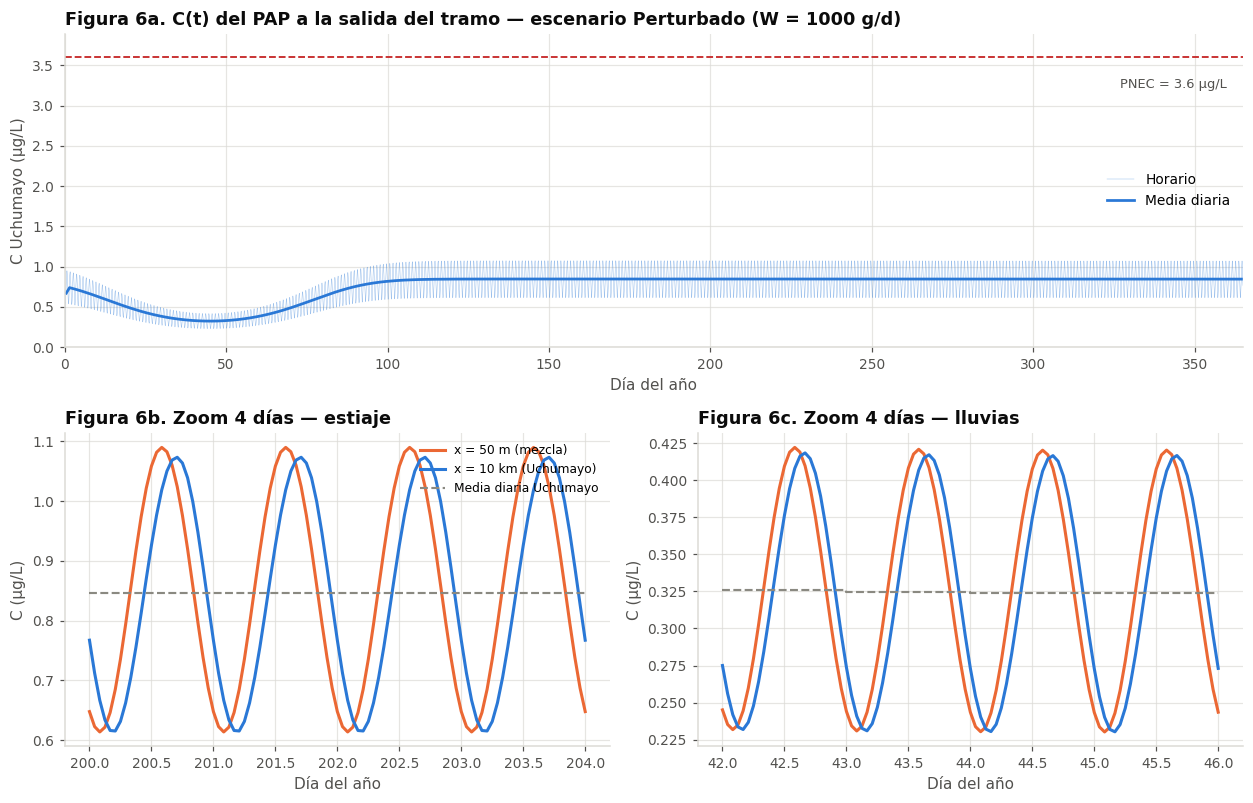

In [19]:
fig = plt.figure(figsize=(11.5, 7.4))
gs = fig.add_gridspec(2, 2, height_ratios=[1, 1])
a1 = fig.add_subplot(gs[0, :])
a1.plot(t_sim, C_uch*1000, color=COL["s1"], lw=0.3, alpha=0.5, label="Horario")
a1.plot(np.arange(len(C_uch_d)) + 0.5, C_uch_d*1000, color=COL["s1"], lw=1.8, label="Media diaria")
a1.axhline(PNEC*1000, color=COL["crit"], lw=1.2, ls="--")
a1.text(360, PNEC*1000*0.93, "PNEC = 3.6 µg/L", ha="right", va="top", fontsize=8.5, color=COL["ink2"])
a1.set_ylim(0, PNEC*1000*1.08); a1.set_xlim(0, 365)
a1.set_xlabel("Día del año"); a1.set_ylabel("C Uchumayo (µg/L)"); a1.legend(loc="center right")
a1.set_title("Figura 6a. C(t) del PAP a la salida del tramo — escenario Perturbado (W = 1000 g/d)")

for a_, d0, lab in [(fig.add_subplot(gs[1, 0]), 200, "estiaje"), (fig.add_subplot(gs[1, 1]), 42, "lluvias")]:
    m = (t_sim >= d0) & (t_sim <= d0 + 4)
    a_.plot(t_sim[m], C_pert[m, 0]*1000, color=COL["s2"], label="x = 50 m (mezcla)")
    a_.plot(t_sim[m], C_uch[m]*1000, color=COL["s1"], label="x = 10 km (Uchumayo)")
    dd = np.arange(d0, d0 + 4)
    a_.step(np.r_[dd, d0 + 4], np.r_[C_uch_d[dd], C_uch_d[d0 + 3]]*1000, where="post",
            color=COL["muted"], lw=1.4, ls="--", label="Media diaria Uchumayo")
    a_.set_xlabel("Día del año"); a_.set_ylabel("C (µg/L)")
    a_.set_title(f"Figura 6{'b' if lab=='estiaje' else 'c'}. Zoom 4 días — {lab}")
fig.axes[1].legend(loc="upper right", fontsize=8)
fig.tight_layout(); guardar(fig, "fig06_C_t_procesos"); plt.show()

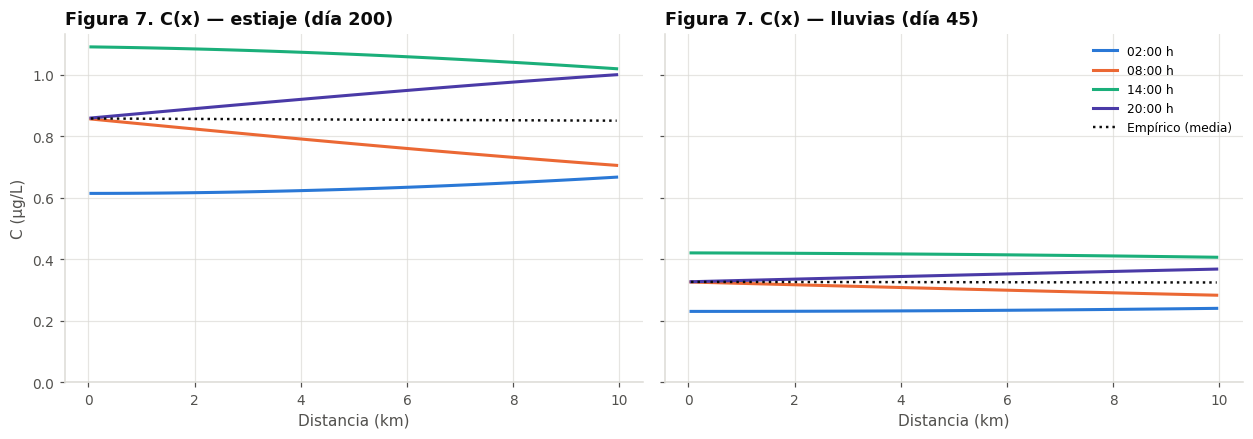

In [20]:
fig, ax = plt.subplots(1, 2, figsize=(11.5, 4.1), sharey=True)
for a_, d0, lab in [(ax[0], 200, "estiaje (día 200)"), (ax[1], 45, "lluvias (día 45)")]:
    for j, hh in enumerate([2, 8, 14, 20]):
        idx = int(round((d0 + hh/24)*24))
        a_.plot(X_SEG/1000, C_pert[idx]*1000, color=SERIES[j], label=f"{hh:02d}:00 h")
    f = forzantes(d0 + 0.5)
    hq = hid_rapida(f["Q_rio"] + f["Q_ef"])
    a_.plot(X_SEG/1000, C_empirico(X_SEG, W_BASE, f["Q_rio"], Q_EF, KB["k_total"], hq["u"])*1000,
            color=COL["ink"], ls=":", lw=1.6, label="Empírico (media)")
    a_.set_xlabel("Distancia (km)"); a_.set_title(f"Figura 7. C(x) — {lab}")
ax[0].set_ylabel("C (µg/L)"); ax[0].set_ylim(0, None); ax[1].legend(loc="upper right", fontsize=8)
fig.tight_layout(); guardar(fig, "fig07_C_x_procesos"); plt.show()

## 6.4 Biota: fitoplancton → Daphnia → trucha (Control, Perturbado y prueba de estrés)

Además de los escenarios del documento se corre un escenario **Estrés hipotético (100 × W)** solo para
comprobar que el acople tóxico–biota funciona (con W = 1000 g/d el efecto es imperceptible). Como el
modelo del tóxico es lineal en W, su concentración es exactamente 100 veces la del Perturbado.

In [21]:
# ============================================================================
# 6.4 MODELO DE BIOTA
# ============================================================================
PB = dict(  # parámetros de biota (supuestos, órdenes de magnitud tipo AQUATOX)
    fito=dict(mu_max=2.0, r=0.10, m=0.05, I_opt=80.0, T_opt=20.0, T_min=5.0, K_N=0.02, B_up=0.05),
    daph=dict(g_max=1.0, K_g=0.10, eff=0.40, r=0.15, m=0.05, T_opt=20.0, T_min=2.0, B_up=0.005),
    trucha=dict(c_max=0.04, K_t=0.10, eff=0.60, r=0.008, m0=0.002, m_dd=0.012, T_opt=15.0, T_min=0.0, F_alt=0.20),
)
B0 = [0.05, 0.005, 0.35]   # trucha cerca de su equilibrio estacional
PE = list(ESPECIES.values())

def f_T(T, T_opt, T_min):
    return np.exp(-2.3*np.abs(T - T_opt)/(T_opt - T_min))

def f_luz_steele(I0, kext, h, I_opt):
    """Steele integrado en la profundidad (Lambert–Beer)."""
    if I0 <= 0: return 0.0
    return np.e/(kext*h) * (np.exp(-I0/I_opt*np.exp(-kext*h)) - np.exp(-I0/I_opt))

def simular_biota(C_expo_t, t_ref=t_sim, dias=365):
    """C_expo_t: concentración promedio del tramo en t_ref (mg/L)."""
    pf, pd_, pt_ = PB["fito"], PB["daph"], PB["trucha"]
    def rhs(t, y):
        Bp, Bd, Bt, Cp, Cd, Ct = np.maximum(y, 0)
        f  = forzantes(t)
        hq = hid_rapida(f["Q_rio"] + f["Q_ef"])
        w  = (f["Q_rio"] + f["Q_ef"])*DAY/(hq["A"]*L_TRAMO)            # washout 1/d
        C  = np.interp(t, t_ref, C_expo_t)
        kext = 0.5 + 0.06*f["SS"]
        # toxicidad
        mt = [m_tox(Ci/p["BCF"], p) for Ci, p in zip((Cp, Cd, Ct), PE)]
        # fitoplancton
        mu_p = pf["mu_max"]*f_luz_steele(f["I0"], kext, hq["h"], pf["I_opt"]) \
               *f_T(f["T"], pf["T_opt"], pf["T_min"])*f["N"]/(pf["K_N"] + f["N"])
        graz = pd_["g_max"]*f_T(f["T"], pd_["T_opt"], pd_["T_min"])*Bp/(pd_["K_g"] + Bp)*Bd
        p_p  = graz/max(Bp, 1e-12)
        dBp  = (mu_p - pf["r"] - pf["m"] - mt[0] - p_p - w)*Bp + w*pf["B_up"]
        # Daphnia
        food = Bd + pt_["F_alt"]
        ing_t = pt_["c_max"]*f_T(f["T"], pt_["T_opt"], pt_["T_min"])*food/(pt_["K_t"] + food)
        p_d  = ing_t*Bt/food
        mu_d = pd_["eff"]*graz/max(Bd, 1e-12)
        dBd  = (mu_d - pd_["r"] - pd_["m"] - mt[1] - p_d - w)*Bd + w*pd_["B_up"]
        # trucha
        dBt  = (pt_["eff"]*ing_t - pt_["r"] - pt_["m0"] - pt_["m_dd"]*Bt - mt[2])*Bt
        # concentración interna
        dC = [p["BCF"]*p["k2"]*C - p["k2"]*Ci for Ci, p in zip((Cp, Cd, Ct), PE)]
        return [dBp, dBd, dBt, *dC]
    t_eval = np.arange(0, dias*24 + 1)/24.0
    sol = solve_ivp(rhs, (0, dias), B0 + [0, 0, 0], method="LSODA", t_eval=t_eval,
                    max_step=1/24, rtol=1e-6, atol=1e-10)
    return pd.DataFrame(sol.y.T, columns=["B_fito", "B_daphnia", "B_trucha", "Corg_fito", "Corg_daphnia", "Corg_trucha"]).assign(t_d=sol.t)

t0 = time.time()
BIO = {"Control": simular_biota(C_ctrl.mean(axis=1)),
       "Perturbado": simular_biota(C_prom),
       "Estrés (100×W)": simular_biota(100*C_prom)}
print(f"Biota resuelta en {time.time()-t0:.1f} s")

Biota resuelta en 22.0 s


In [22]:
sp_cols = [("B_fito", "Fitoplancton"), ("B_daphnia", "Daphnia"), ("B_trucha", "Trucha")]
filas = []
for esc, df in BIO.items():
    for (c, nom), p in zip(sp_cols, PE):
        corg = df[c.replace("B_", "Corg_")]
        ref = BIO["Control"][c]
        filas.append({"Escenario": esc, "Especie": nom,
                      "Biomasa media (mg/L)": df[c].mean(), "Biomasa final (mg/L)": df[c].iloc[-1],
                      "Cambio medio vs Control (%)": 100*(df[c].mean()/ref.mean() - 1),
                      "C_org máx. (mg/kg)": corg.max(),
                      "m_tox máx. (1/d)": float(np.max(m_tox(corg.values/p["BCF"], p)))})
df_bio = pd.DataFrame(filas)
tabla(df_bio, "t15_biota_escenarios", "Tabla 15. Biota por escenario (365 d)", precision=6)
for esc in ("Perturbado", "Estrés (100×W)"):
    for _, r in df_bio[df_bio["Escenario"] == esc].iterrows():
        anotar(f"dB_{esc[:4]}_{r['Especie']}", r["Cambio medio vs Control (%)"], "%", f"{esc}: cambio de biomasa {r['Especie']}")
for c in ["B_fito", "B_daphnia", "B_trucha"]:
    pd.DataFrame({esc: df[c].values for esc, df in BIO.items()}).assign(t_d=t_sim).to_csv(RES_DIR/f"serie_biomasa_{c}.csv", index=False)

**Tabla 15. Biota por escenario (365 d)**  ·  `tif_pap/resultados/t15_biota_escenarios.csv`

Escenario,Especie,Biomasa media (mg/L),Biomasa final (mg/L),Cambio medio vs Control (%),C_org máx. (mg/kg),m_tox máx. (1/d)
Control,Fitoplancton,0.050504,0.049527,0.000000,0.000000,-0.000000
Control,Daphnia,0.004921,0.004925,0.000000,0.000000,-0.000000
Control,Trucha,0.306322,0.294929,0.000000,0.000000,-0.000000
Perturbado,Fitoplancton,0.050504,0.049527,-0.000104,0.042312,0.000013
Perturbado,Daphnia,0.004921,0.004925,0.000012,0.022166,0.000000
Perturbado,Trucha,0.306314,0.294915,-0.002594,0.008617,0.000000
Estrés (100×W),Fitoplancton,0.050094,0.048990,-0.812520,4.231165,0.106401
Estrés (100×W),Daphnia,0.004832,0.004801,-1.802977,2.216558,0.260365
Estrés (100×W),Trucha,0.274692,0.232124,-10.325579,0.861689,0.001286


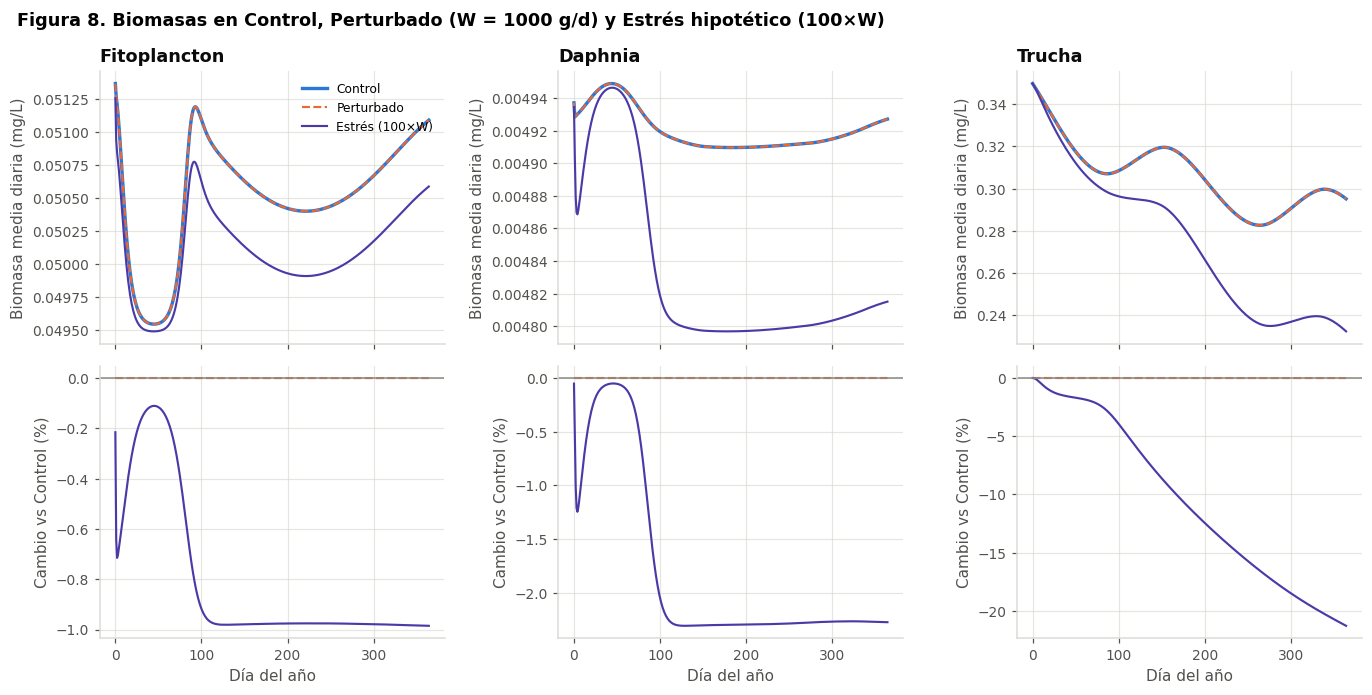

In [23]:
fig, ax = plt.subplots(2, 3, figsize=(12.5, 6.4), sharex=True)
estilos = {"Control": dict(color=COL["s1"], lw=2.2), "Perturbado": dict(color=COL["s2"], lw=1.4, ls="--"),
           "Estrés (100×W)": dict(color=COL["s4"], lw=1.4)}
for j, (c, nom) in enumerate(sp_cols):
    for esc, df in BIO.items():
        df = df[df["t_d"] < 365]
        dd = df.groupby((df["t_d"]//1).astype(int))[c].mean()
        ax[0, j].plot(dd.index, dd.values, label=esc, **estilos[esc])
        if esc != "Control":
            rc = BIO["Control"][BIO["Control"]["t_d"] < 365]
            ref = rc.groupby((rc["t_d"]//1).astype(int))[c].mean()
            ax[1, j].plot(dd.index, 100*(dd.values/ref.values - 1), label=esc, **estilos[esc])
    ax[0, j].set_title(nom); ax[0, j].set_ylabel("Biomasa media diaria (mg/L)")
    ax[1, j].axhline(0, color=COL["muted"], lw=1)
    ax[1, j].set_ylabel("Cambio vs Control (%)"); ax[1, j].set_xlabel("Día del año")
ax[0, 0].legend(loc="upper right", fontsize=8)
fig.suptitle("Figura 8. Biomasas en Control, Perturbado (W = 1000 g/d) y Estrés hipotético (100×W)",
             x=0.01, ha="left", fontweight="bold", fontsize=11.5)
fig.tight_layout(); guardar(fig, "fig08_biomasas"); plt.show()

## 6.5 Oxígeno disuelto (Streeter–Phelps, opcional)

$$D(t)=\frac{k_dL_0}{k_a-k_d}\left(e^{-k_dt}-e^{-k_at}\right)+D_0e^{-k_at},\qquad OD=OD_{sat}-D$$

con $k_a$ de O'Connor–Dobbins ($3.93\,u^{0.5}/h^{1.5}$), corrección de temperatura
($\theta_d=1.047$, $\theta_a=1.024$) y $OD_{sat}$ corregido por altitud. DBO y OD del efluente y del río
son **supuestos** típicos de un efluente secundario.

**Tabla 16. Streeter–Phelps del efluente (15 °C)**  ·  `tif_pap/resultados/t16_streeter_phelps.csv`

k_d (1/d),k_a (1/d),OD_sat 2335 msnm (mg/L),L0 (mg/L),D0 (mg/L),t crítico (d),OD mínimo (mg/L),OD en Uchumayo (mg/L)
0.278,7.593,7.550,4.556,1.154,0.000,6.397,6.942


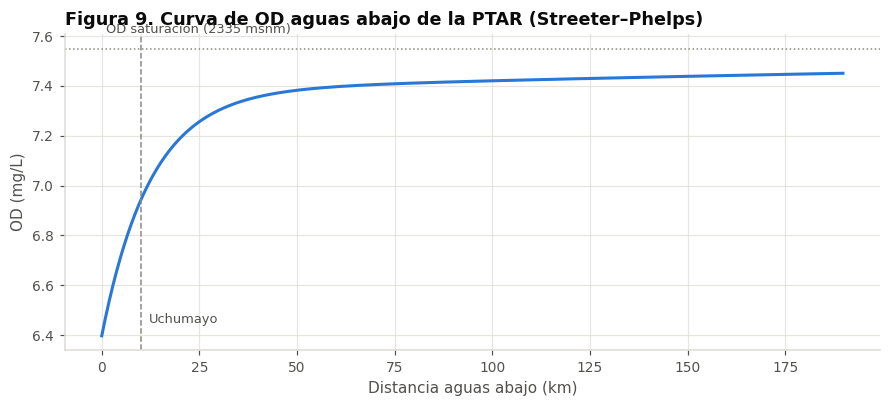

In [24]:
# ============================================================================
# 6.5 STREETER–PHELPS
# ============================================================================
T_SP = 15.0
DBO_EF, DBO_RIO = 25.0, 2.0          # mg/L (supuesto)
OD_EF = 2.0                          # mg/L (supuesto)
kd = 0.35 * 1.047**(T_SP - 20)
ka = 3.93 * HB["u"]**0.5 / HB["h"]**1.5 * 1.024**(T_SP - 20)
ods = OD_sat(T_SP)
L0 = (DBO_EF*Q_EF + DBO_RIO*Q_RIO)/(Q_EF + Q_RIO)
OD0 = (OD_EF*Q_EF + 0.92*ods*Q_RIO)/(Q_EF + Q_RIO)
D0 = ods - OD0
tt = np.linspace(0, 2.0, 400)
D = kd*L0/(ka - kd)*(np.exp(-kd*tt) - np.exp(-ka*tt)) + D0*np.exp(-ka*tt)
arg = ka/kd*(1 - D0*(ka - kd)/(kd*L0))
t_c = 1/(ka - kd)*np.log(arg) if arg > 1 else 0.0   # si arg ≤ 1 el déficit máximo está en la descarga
df_sp = pd.DataFrame([{"k_d (1/d)": kd, "k_a (1/d)": ka, "OD_sat 2335 msnm (mg/L)": ods, "L0 (mg/L)": L0,
                       "D0 (mg/L)": D0, "t crítico (d)": t_c,
                       "OD mínimo (mg/L)": ods - D.max(), "OD en Uchumayo (mg/L)": ods - np.interp(HB["TRH_d"], tt, D)}])
tabla(df_sp, "t16_streeter_phelps", "Tabla 16. Streeter–Phelps del efluente (15 °C)", precision=3)

fig, ax = plt.subplots(figsize=(8.2, 3.8))
ax.plot(tt*HB["u"]*DAY/1000, ods - D, color=COL["s1"])
ax.axhline(ods, color=COL["muted"], lw=1, ls=":")
ax.text(1, ods + 0.05, "OD saturación (2335 msnm)", fontsize=8.5, color=COL["ink2"], va="bottom")
ax.axvline(L_TRAMO/1000, color=COL["muted"], lw=1, ls="--")
ax.text(L_TRAMO/1000 + 2, ods - D.max() + 0.05, "Uchumayo", fontsize=8.5, color=COL["ink2"])
ax.set_xlabel("Distancia aguas abajo (km)"); ax.set_ylabel("OD (mg/L)")
ax.set_title("Figura 9. Curva de OD aguas abajo de la PTAR (Streeter–Phelps)")
fig.tight_layout(); guardar(fig, "fig09_streeter_phelps"); plt.show()

---
# 7. Modelo integrado: procesos + inteligencia artificial (sección 6)

$$C_{integrado}=C_{procesos}(X)+g_{ML}(X),\qquad \varepsilon = C_{obs}-C_{procesos}$$

$X=[Q_{río},\,T,\,pH,\,OD,\,SS,\,I_0,\,W]$.

## 7.1 Diseño del experimento sintético (Monte Carlo)

No existen mediciones de PAP en el Chili, así que se generan **pseudo-observaciones** con el propio
modelo de procesos, perturbando entradas y parámetros (N = 2000):

1. **Entradas observables $X$** sorteadas en sus rangos: $W\sim U(648,1426)$ g/d, $Q_{río}\sim U(10,36)$ m³/s,
   $T\sim U(12,18)$ °C, pH $\sim U(7.0,8.3)$, SS ligado al caudal con ruido, $I_0$ según hora del día y
   nubosidad, OD como fracción de saturación.
2. **$C_{procesos}$**: modelo de la sección 6 con parámetros nominales (lo que se correría sin calibrar).
3. **$C_{obs}$ (pseudo-observación)**: el mismo modelo, pero con lo que el modelo nominal desconoce:
   * $k$ inciertos: $t_{1/2,bio}\sim U(30,120)$ d, $\theta\sim U(1.03,1.08)$; geometría $n\sim U(0.035,0.05)$, $B\sim U(15,25)$ m;
   * fotólisis con apantallamiento por turbidez y profundidad ($t_{1/2}$ a pleno sol $\sim U(0.5,2)$ d);
   * autooxidación del aminofenol catalizada por pH, $k_{ox}=k_{ox,8}\,10^{pH-8}$ ($t_{1/2}$ a pH 8 $\sim U(1,4)$ d);
   * biodegradación limitada por OD (Monod);
   * carga difusa de fondo aguas arriba $M_{up}\sim U(50,250)$ g/d (el documento asume $C_{up}=0$);
   * error analítico log-normal del 8 %.
4. La salida es la concentración en Uchumayo (fin del tramo) en estado estacionario: como el TRH (≈ 2.5 h)
   es corto frente a la variación de las condiciones, cada muestra representa una campaña puntual.

Con esa nube se entrena la IA (70 %) y se valida (30 %), y se comparan los modelos con **RMSE, R² y NSE**.

In [25]:
# ============================================================================
# 7.1 GENERACIÓN MONTE CARLO
# ============================================================================
N_MC = 2000
FEATS = ["Q_rio", "T", "pH", "OD", "SS", "I0", "W"]

def estacionario_fin(Q_rio, W, T, I0, SS, pH, OD, p, hid=None):
    J, b, _ = sistema_rio(Q_rio, Q_EF, W, T, I0, SS, pH, OD, p, hid)
    y = spsolve(J, -b)
    return y[:N_SEG]

rng = np.random.default_rng(7)
mc = pd.DataFrame({
    "W":     rng.uniform(648, 1426, N_MC),
    "Q_rio": rng.uniform(10, 36, N_MC),
    "T":     rng.uniform(12, 18, N_MC),
    "pH":    rng.uniform(7.0, 8.3, N_MC),
})
lluv = np.clip((mc["Q_rio"] - Q_RIO)/22.0, 0, 1)
mc["SS"] = (25 + 400*lluv)*rng.lognormal(0, 0.3, N_MC)
hora = rng.uniform(0, 24, N_MC)
mc["I0"] = rng.uniform(250, 470, N_MC)*np.maximum(0, np.sin(np.pi*(hora - 6)/12))
mc["OD"] = OD_sat(mc["T"])*rng.uniform(0.85, 0.98, N_MC)

# parámetros ocultos de la "realidad"
oc = pd.DataFrame({
    "t12_bio": rng.uniform(30, 120, N_MC), "theta": rng.uniform(1.03, 1.08, N_MC),
    "n": rng.uniform(0.035, 0.05, N_MC), "B": rng.uniform(15, 25, N_MC),
    "t12_foto_sol": rng.uniform(0.5, 2.0, N_MC), "t12_ox8": rng.uniform(1.0, 4.0, N_MC),
    "M_up": rng.uniform(50, 250, N_MC), "ruido": rng.lognormal(0, 0.08, N_MC),
})

t0 = time.time()
C_proc, C_obs, C_real, perfiles = np.empty(N_MC), np.empty(N_MC), np.empty(N_MC), np.empty((N_MC, N_SEG))
for i, (r, o) in enumerate(zip(mc.itertuples(index=False), oc.itertuples(index=False))):
    Cn = estacionario_fin(r.Q_rio, r.W, r.T, r.I0, r.SS, r.pH, r.OD, PARAM_NOMINAL)
    C_proc[i] = Cn[-1]
    p_real = dict(PARAM_NOMINAL, t12_bio=o.t12_bio, theta=o.theta, foto_pantalla=True,
                  kfoto_max=LN2/o.t12_foto_sol, kox8=LN2/o.t12_ox8, od_monod=True, M_up=o.M_up)
    hr_ = hidraulica(r.Q_rio + Q_EF, B=o.B, n=o.n)
    Cr = estacionario_fin(r.Q_rio, r.W, r.T, r.I0, r.SS, r.pH, r.OD, p_real, hr_)
    perfiles[i] = Cr
    C_real[i] = Cr[-1]
    C_obs[i] = Cr[-1]*o.ruido
mc["C_procesos"], mc["C_obs"] = C_proc, C_obs
print(f"Monte Carlo: {N_MC} corridas (x2 modelos) en {time.time()-t0:.1f} s")

mc.join(oc).to_csv(RES_DIR/"monte_carlo_muestras.csv", index=False)
q = lambda v: np.percentile(v, [5, 50, 95])
df_mc = pd.DataFrame([["C_procesos (mg/L)", *q(C_proc), C_proc.mean()],
                      ["C_obs pseudo-observada (mg/L)", *q(C_obs), C_obs.mean()],
                      ["Residuo ε = C_obs − C_procesos (mg/L)", *q(C_obs - C_proc), (C_obs - C_proc).mean()],
                      ["HQ (C_obs)", *q(C_obs/PNEC), (C_obs/PNEC).mean()]],
                     columns=["Variable", "P5", "P50", "P95", "Media"])
tabla(df_mc, "t17_monte_carlo_percentiles", "Tabla 17. Incertidumbre Monte Carlo (percentiles 5 y 95)", precision=6)
anotar("MC_P5", np.percentile(C_obs, 5), "mg/L", "Monte Carlo: P5 de C en Uchumayo")
anotar("MC_P95", np.percentile(C_obs, 95), "mg/L", "Monte Carlo: P95 de C en Uchumayo")

Monte Carlo: 2000 corridas (x2 modelos) en 2.3 s


**Tabla 17. Incertidumbre Monte Carlo (percentiles 5 y 95)**  ·  `tif_pap/resultados/t17_monte_carlo_percentiles.csv`

Variable,P5,P50,P95,Media
C_procesos (mg/L),0.000265,0.000487,0.000989,0.000541
C_obs pseudo-observada (mg/L),0.000303,0.000545,0.001105,0.000610
Residuo ε = C_obs − C_procesos (mg/L),-0.000026,0.000061,0.000196,0.000069
HQ (C_obs),0.084153,0.151300,0.307026,0.169436


0.0011052924386397468

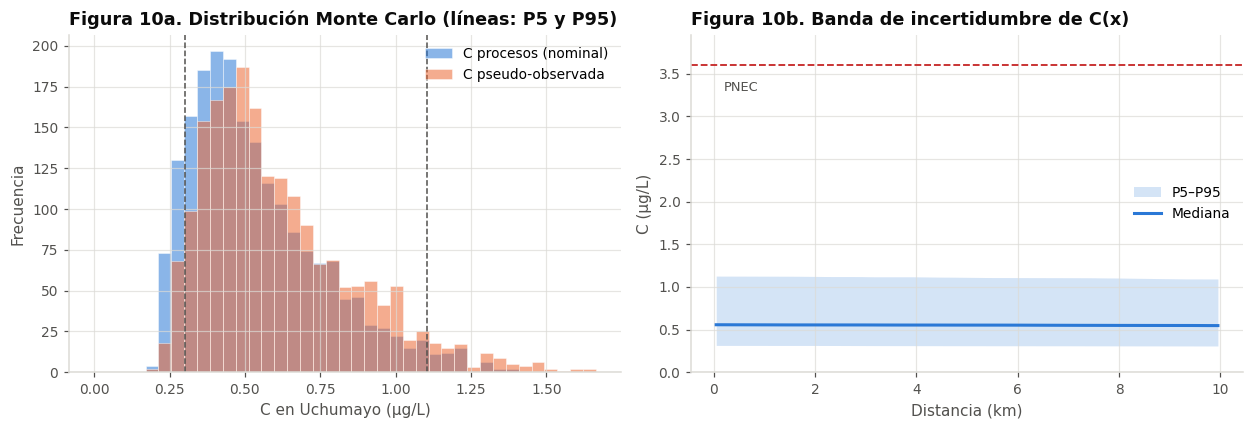

In [26]:
fig, ax = plt.subplots(1, 2, figsize=(11.5, 4))
bins = np.linspace(0, max(C_obs.max(), C_proc.max())*1000, 40)
ax[0].hist(C_proc*1000, bins=bins, color=COL["s1"], alpha=0.55, label="C procesos (nominal)", edgecolor="white", linewidth=0.5)
ax[0].hist(C_obs*1000, bins=bins, color=COL["s2"], alpha=0.55, label="C pseudo-observada", edgecolor="white", linewidth=0.5)
for v in np.percentile(C_obs, [5, 95])*1000:
    ax[0].axvline(v, color=COL["ink2"], lw=1, ls="--")
ax[0].set_xlabel("C en Uchumayo (µg/L)"); ax[0].set_ylabel("Frecuencia"); ax[0].legend()
ax[0].set_title("Figura 10a. Distribución Monte Carlo (líneas: P5 y P95)")

p5, p50, p95 = np.percentile(perfiles*1000, [5, 50, 95], axis=0)
ax[1].fill_between(X_SEG/1000, p5, p95, color=COL["s1"], alpha=0.2, lw=0, label="P5–P95")
ax[1].plot(X_SEG/1000, p50, color=COL["s1"], label="Mediana")
ax[1].axhline(PNEC*1000, color=COL["crit"], lw=1.2, ls="--")
ax[1].text(0.2, PNEC*1000*0.95, "PNEC", fontsize=8.5, color=COL["ink2"], va="top")
ax[1].set_ylim(0, PNEC*1000*1.1)
ax[1].set_xlabel("Distancia (km)"); ax[1].set_ylabel("C (µg/L)"); ax[1].legend(loc="center right")
ax[1].set_title("Figura 10b. Banda de incertidumbre de C(x)")
fig.tight_layout(); guardar(fig, "fig10_monte_carlo"); plt.show()

## 7.2 Entrenamiento: línea base empírica, IA pura e integrado

* **Empírico (dilución):** $W/(Q_{ef}+Q_{río})\,e^{-kx/u}$ con $k=0.1$ 1/d.
* **Regresión potencial:** $C=aW^bQ_{río}^c$ ajustada por mínimos cuadrados en log (se espera $b\approx1$, $c\approx-1$).
* **Procesos:** modelo nominal de la sección 6.
* **IA pura:** Random Forest que predice $C$ directamente desde $X$ (sin física).
* **Integrado:** $C_{procesos}+g_{ML}(X)$, con $g_{ML}$ = Random Forest entrenado sobre el residuo.
* **Techo:** la pseudo-realidad sin el error analítico del 8 %; ningún modelo puede superar ese NSE, porque
  el ruido y la carga de fondo aleatoria no son predecibles desde $X$.

Métricas: $RMSE=\sqrt{\sum(y_{obs}-y_{pred})^2/n}$; $NSE=1-\sum(y_{obs}-y_{pred})^2/\sum(y_{obs}-\bar y_{obs})^2$.
Como la expresión de R² del documento coincide con la del NSE, aquí R² se reporta como el coeficiente de
determinación de la regresión observado–predicho ($r^2$ de Pearson), para que ambas métricas aporten
información distinta.

In [27]:
# ============================================================================
# 7.2 MODELOS Y MÉTRICAS
# ============================================================================
def rmse(o, p): return float(np.sqrt(np.mean((o - p)**2)))
def r2(o, p):   return float(np.corrcoef(o, p)[0, 1]**2)
def nse(o, p):  return float(1 - np.sum((o - p)**2)/np.sum((o - np.mean(o))**2))

idx_tr, idx_te = train_test_split(np.arange(N_MC), test_size=0.30, random_state=42)
tr, te = mc.iloc[idx_tr], mc.iloc[idx_te]
Xtr, Xte = tr[FEATS].values, te[FEATS].values

# Empírico de dilución
def pred_empirico(df):
    u = np.array([hid_rapida(q + Q_EF)["u"] for q in df["Q_rio"]])
    return C_empirico(L_TRAMO, df["W"].values, df["Q_rio"].values, Q_EF, 0.1, u)

# Regresión potencial en log
A_ls = np.column_stack([np.ones(len(tr)), np.log(tr["W"]), np.log(tr["Q_rio"])])
coef, *_ = np.linalg.lstsq(A_ls, np.log(tr["C_obs"]), rcond=None)
a_pot, b_pot, c_pot = np.exp(coef[0]), coef[1], coef[2]
pred_potencial = lambda df: a_pot * df["W"].values**b_pot * df["Q_rio"].values**c_pot

# IA pura
rf_pura = RandomForestRegressor(n_estimators=500, min_samples_leaf=3, random_state=0, n_jobs=-1)
rf_pura.fit(Xtr, tr["C_obs"])

# Integrado (aprendizaje del residuo)
rf_res = RandomForestRegressor(n_estimators=500, min_samples_leaf=3, random_state=0, n_jobs=-1)
rf_res.fit(Xtr, tr["C_obs"] - tr["C_procesos"])
pred_integrado = lambda df: df["C_procesos"].values + rf_res.predict(df[FEATS].values)

PRED = {
    "Empírico (dilución)": pred_empirico(te),
    "Regresión potencial": pred_potencial(te),
    "Procesos (nominal)": te["C_procesos"].values,
    "IA pura (RF)": rf_pura.predict(Xte),
    "Integrado (procesos + RF)": pred_integrado(te),
}
y_te = te["C_obs"].values
df_met = pd.DataFrame([{"Modelo": k, "RMSE (mg/L)": rmse(y_te, v), "RMSE (% de la media)": 100*rmse(y_te, v)/y_te.mean(),
                        "R²": r2(y_te, v), "NSE": nse(y_te, v), "Sesgo medio (mg/L)": float(np.mean(v - y_te))}
                       for k, v in PRED.items()])
# Techo de desempeño: la "realidad" sin error analítico (lo máximo alcanzable por cualquier modelo)
v_ = C_real[idx_te]
df_met.loc[len(df_met)] = ["Techo: realidad sin error analítico", rmse(y_te, v_), 100*rmse(y_te, v_)/y_te.mean(),
                           r2(y_te, v_), nse(y_te, v_), float(np.mean(v_ - y_te))]
tabla(df_met, "t18_metricas_modelos", "Tabla 18. Desempeño en el conjunto de validación (n = 600)", precision=6)

df_pot = pd.DataFrame([{"a": a_pot, "b (exp. W)": b_pot, "c (exp. Q_río)": c_pot}])
tabla(df_pot, "t19_regresion_potencial", "Tabla 19. Regresión potencial C = a·W^b·Q^c (esperado b ≈ 1, c ≈ −1)", precision=6)

for _, r in df_met.iterrows():
    anotar(f"NSE_{r['Modelo']}", r["NSE"], "-", f"NSE validación: {r['Modelo']}")
    anotar(f"RMSE_{r['Modelo']}", r["RMSE (mg/L)"], "mg/L", f"RMSE validación: {r['Modelo']}")

**Tabla 18. Desempeño en el conjunto de validación (n = 600)**  ·  `tif_pap/resultados/t18_metricas_modelos.csv`

Modelo,RMSE (mg/L),RMSE (% de la media),R²,NSE,Sesgo medio (mg/L)
Empírico (dilución),0.000100,16.402754,0.925795,0.835898,-0.000072
Regresión potencial,0.000067,10.890217,0.927967,0.927664,-0.000004
Procesos (nominal),0.000099,16.214277,0.925739,0.839647,-0.000070
IA pura (RF),0.000070,11.447586,0.920122,0.920070,-0.000001
Integrado (procesos + RF),0.000067,10.891073,0.927783,0.927653,-0.000001
Techo: realidad sin error analítico,0.000057,9.337948,0.946908,0.946816,-0.000002


**Tabla 19. Regresión potencial C = a·W^b·Q^c (esperado b ≈ 1, c ≈ −1)**  ·  `tif_pap/resultados/t19_regresion_potencial.csv`

a,b (exp. W),c (exp. Q_río)
0.000023,0.873369,-0.920510


In [28]:
# ---- Validación cruzada (5 pliegues) para comprobar la estabilidad ----------
kf = KFold(n_splits=5, shuffle=True, random_state=1)
cv = []
for k_, (a_i, b_i) in enumerate(kf.split(mc)):
    A_, B_ = mc.iloc[a_i], mc.iloc[b_i]
    m1 = RandomForestRegressor(n_estimators=300, min_samples_leaf=3, random_state=0, n_jobs=-1).fit(A_[FEATS], A_["C_obs"] - A_["C_procesos"])
    m2 = RandomForestRegressor(n_estimators=300, min_samples_leaf=3, random_state=0, n_jobs=-1).fit(A_[FEATS], A_["C_obs"])
    y = B_["C_obs"].values
    cv.append({"Pliegue": k_ + 1,
               "NSE procesos": nse(y, B_["C_procesos"].values),
               "NSE IA pura": nse(y, m2.predict(B_[FEATS])),
               "NSE integrado": nse(y, B_["C_procesos"].values + m1.predict(B_[FEATS]))})
df_cv = pd.DataFrame(cv)
df_cv.loc[len(df_cv)] = ["Media", *df_cv.iloc[:, 1:].mean().values]
tabla(df_cv, "t20_validacion_cruzada", "Tabla 20. Validación cruzada de 5 pliegues (NSE)", precision=4)

**Tabla 20. Validación cruzada de 5 pliegues (NSE)**  ·  `tif_pap/resultados/t20_validacion_cruzada.csv`

Pliegue,NSE procesos,NSE IA pura,NSE integrado
1,0.8586,0.9367,0.9370
2,0.8521,0.9238,0.9313
3,0.8464,0.9151,0.9286
4,0.8538,0.9143,0.9218
5,0.8158,0.9103,0.9161
Media,0.8454,0.9200,0.9270


,Pliegue,NSE procesos,NSE IA pura,NSE integrado
0,1,0.858642,0.936711,0.937021
1,2,0.852101,0.923779,0.931290
2,3,0.846370,0.915058,0.928622
3,4,0.853833,0.914257,0.921808
4,5,0.815815,0.910296,0.916053
5,Media,0.845352,0.920020,0.926959


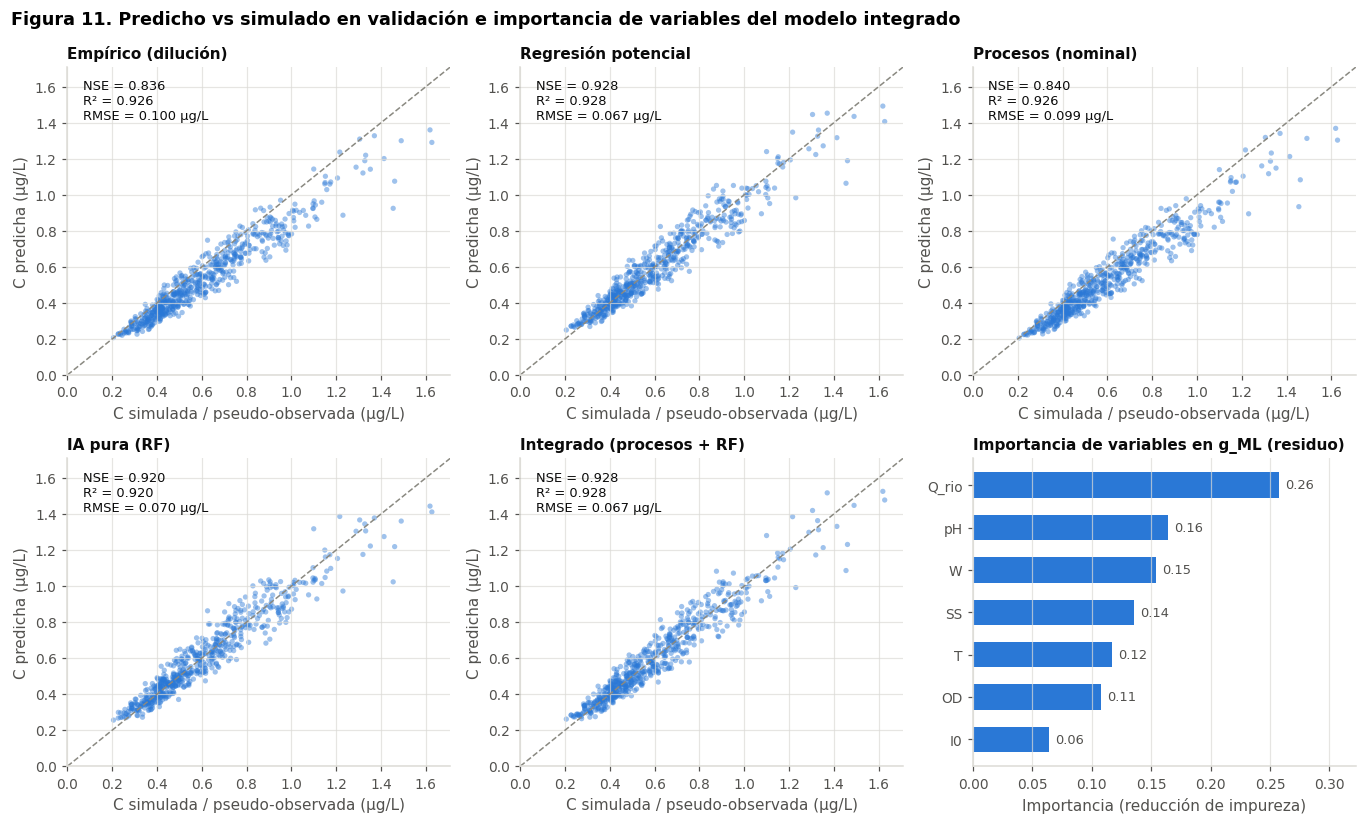

**Tabla 21. Importancia de variables en el residuo**  ·  `tif_pap/resultados/t21_importancia_variables.csv`

Variable,Importancia
Q_rio,0.2578
pH,0.1644
W,0.1538
SS,0.1355
T,0.1167
OD,0.1076
I0,0.0642


,Variable,Importancia
0,Q_rio,0.257813
1,pH,0.164441
2,W,0.153762
3,SS,0.135512
4,T,0.116662
5,OD,0.107621
6,I0,0.064189


In [29]:
fig, ax = plt.subplots(2, 3, figsize=(12.5, 7.6))
lim = [0, max(y_te.max(), max(v.max() for v in PRED.values()))*1000*1.05]
for a_, (nom, v) in zip(ax.flat, PRED.items()):
    a_.plot(lim, lim, color=COL["muted"], lw=1, ls="--")
    a_.scatter(y_te*1000, v*1000, s=12, color=COL["s1"], alpha=0.45, edgecolor="none")
    fila = df_met[df_met["Modelo"] == nom].iloc[0]
    a_.text(0.04, 0.96, f"NSE = {fila['NSE']:.3f}\nR² = {fila['R²']:.3f}\nRMSE = {fila['RMSE (mg/L)']*1000:.3f} µg/L",
            transform=a_.transAxes, va="top", fontsize=8.5, color=COL["ink"])
    a_.set_xlim(lim); a_.set_ylim(lim); a_.set_title(nom, fontsize=10)
    a_.set_xlabel("C simulada / pseudo-observada (µg/L)"); a_.set_ylabel("C predicha (µg/L)")

imp = pd.Series(rf_res.feature_importances_, index=FEATS).sort_values()
a_ = ax[1, 2]
a_.barh(imp.index, imp.values, color=COL["s1"], height=0.6)
a_.set_title("Importancia de variables en g_ML (residuo)", fontsize=10); a_.set_xlabel("Importancia (reducción de impureza)")
a_.set_xlim(0, imp.max()*1.25); a_.grid(axis="y", visible=False)
for y_, v in enumerate(imp.values):
    a_.text(v + imp.max()*0.02, y_, f"{v:.2f}", va="center", fontsize=8.5, color=COL["ink2"])
fig.suptitle("Figura 11. Predicho vs simulado en validación e importancia de variables del modelo integrado",
             x=0.01, ha="left", fontweight="bold", fontsize=11.5)
fig.tight_layout(); guardar(fig, "fig11_predicho_vs_simulado"); plt.show()
tabla(pd.DataFrame({"Variable": imp.index[::-1], "Importancia": imp.values[::-1]}),
      "t21_importancia_variables", "Tabla 21. Importancia de variables en el residuo", precision=4)

## 7.3 Incertidumbre de la predicción integrada

Se entrenan dos modelos de *gradient boosting* con pérdida cuantil (α = 0.05 y 0.95) sobre el residuo, de
modo que el integrado entrega un intervalo P5–P95 para cada predicción. Como los cuantiles de boosting suelen
quedar estrechos, el intervalo se calibra con una partición separada (regresión cuantil conformal) y se
verifica su cobertura en validación.

In [30]:
# ============================================================================
# 7.3 INTERVALOS DE PREDICCIÓN (cuantiles 5 y 95)
# ============================================================================
# 80 % del entrenamiento ajusta los cuantiles; 20 % calibra (regresión cuantil conformal, CQR)
i_fit, i_cal = train_test_split(np.arange(len(tr)), test_size=0.20, random_state=3)
eps_tr = (tr["C_obs"] - tr["C_procesos"]).values
qmod = {}
for alpha in (0.05, 0.95):
    qmod[alpha] = GradientBoostingRegressor(loss="quantile", alpha=alpha, n_estimators=400, max_depth=3,
                                            learning_rate=0.05, min_samples_leaf=10, random_state=0)
    qmod[alpha].fit(Xtr[i_fit], eps_tr[i_fit])
s_cal = np.maximum(qmod[0.05].predict(Xtr[i_cal]) - eps_tr[i_cal], eps_tr[i_cal] - qmod[0.95].predict(Xtr[i_cal]))
Q_CONF = np.quantile(s_cal, min(1.0, 0.90*(1 + 1/len(i_cal))))
def intervalo(C_proc_, X_):
    return (C_proc_ + qmod[0.05].predict(X_) - Q_CONF, C_proc_ + qmod[0.95].predict(X_) + Q_CONF)

lo0 = te["C_procesos"].values + qmod[0.05].predict(Xte)
hi0 = te["C_procesos"].values + qmod[0.95].predict(Xte)
lo, hi = intervalo(te["C_procesos"].values, Xte)
cob0 = np.mean((y_te >= lo0) & (y_te <= hi0))*100
cobertura = np.mean((y_te >= lo) & (y_te <= hi))*100
df_unc = pd.DataFrame([{"Cobertura sin calibrar (%)": cob0, "Cobertura P5–P95 calibrada (%)": cobertura, "Nominal (%)": 90.0,
                        "Ancho medio del intervalo (mg/L)": float(np.mean(hi - lo)),
                        "Ancho medio relativo (%)": float(100*np.mean((hi - lo)/y_te))}])
tabla(df_unc, "t22_incertidumbre_integrado", "Tabla 22. Intervalos de predicción del modelo integrado", precision=5)
anotar("cobertura_P5_P95", cobertura, "%", "Cobertura del intervalo P5–P95 (integrado)")

**Tabla 22. Intervalos de predicción del modelo integrado**  ·  `tif_pap/resultados/t22_incertidumbre_integrado.csv`

Cobertura sin calibrar (%),Cobertura P5–P95 calibrada (%),Nominal (%),Ancho medio del intervalo (mg/L),Ancho medio relativo (%)
79.16667,87.16667,90.00000,0.00019,32.08811


87.16666666666667

## 7.4 Aplicación del modelo integrado a la serie horaria de 365 días

$C_{integrado}(t)=C_{procesos}(t)+g_{ML}(X(t))$, usando la salida horaria del modelo de procesos en Uchumayo
(sección 6.3) y los forzantes horarios como vector $X(t)$.

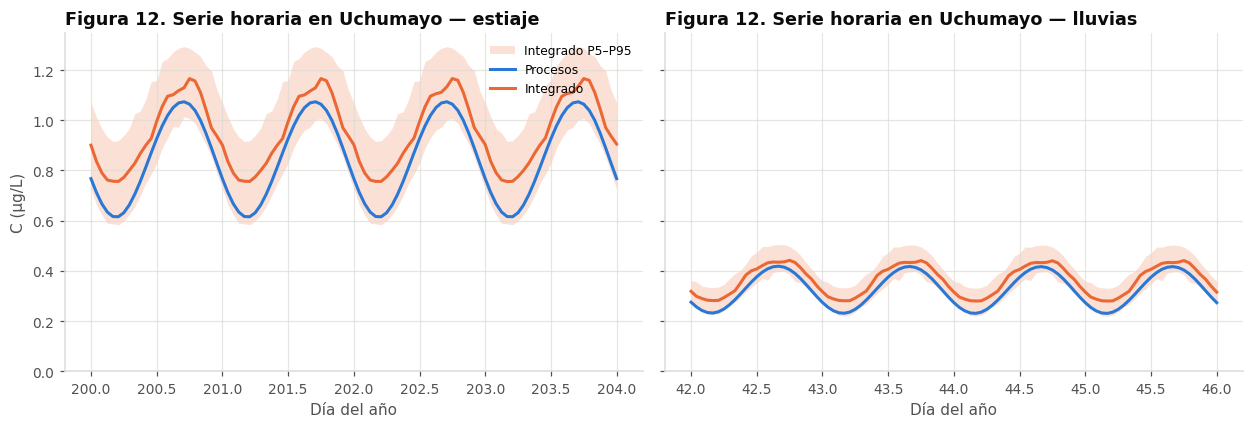

**Tabla 23. Procesos vs integrado sobre la serie horaria anual**  ·  `tif_pap/resultados/t23_integrado_anual.csv`

Indicador,Procesos,Integrado (HQ con P95)
C media anual (mg/L),0.000756,0.000858
C máx. horaria (mg/L),0.001074,0.001195
HQ máx.,0.298249,0.373160


0.3731600994764565

In [31]:
X_t = FZ[FEATS].values
C_int_t = C_uch + rf_res.predict(X_t)
C_lo_t, C_hi_t = intervalo(C_uch, X_t)
pd.DataFrame({"t_d": t_sim, "C_procesos": C_uch, "C_integrado": C_int_t, "P5": C_lo_t, "P95": C_hi_t}) \
  .to_csv(RES_DIR/"serie_horaria_integrado.csv", index=False)

fig, ax = plt.subplots(1, 2, figsize=(11.5, 4), sharey=True)
for a_, d0, lab in [(ax[0], 200, "estiaje"), (ax[1], 42, "lluvias")]:
    m = (t_sim >= d0) & (t_sim <= d0 + 4)
    a_.fill_between(t_sim[m], C_lo_t[m]*1000, C_hi_t[m]*1000, color=COL["s2"], alpha=0.2, lw=0, label="Integrado P5–P95")
    a_.plot(t_sim[m], C_uch[m]*1000, color=COL["s1"], label="Procesos")
    a_.plot(t_sim[m], C_int_t[m]*1000, color=COL["s2"], label="Integrado")
    a_.set_xlabel("Día del año"); a_.set_title(f"Figura 12. Serie horaria en Uchumayo — {lab}")
ax[0].set_ylabel("C (µg/L)"); ax[0].set_ylim(0, None); ax[0].legend(loc="upper right", fontsize=8)
fig.tight_layout(); guardar(fig, "fig12_integrado_serie_horaria"); plt.show()

df_int = pd.DataFrame([
    ("C media anual (mg/L)", C_uch.mean(), C_int_t.mean()),
    ("C máx. horaria (mg/L)", C_uch.max(), C_int_t.max()),
    ("HQ máx.", C_uch.max()/PNEC, C_hi_t.max()/PNEC),
], columns=["Indicador", "Procesos", "Integrado (HQ con P95)"])
tabla(df_int, "t23_integrado_anual", "Tabla 23. Procesos vs integrado sobre la serie horaria anual", precision=6)
anotar("C_int_media", C_int_t.mean(), "mg/L", "Integrado: C media anual en Uchumayo")
anotar("HQ_int_P95_max", C_hi_t.max()/PNEC, "-", "Integrado: HQ máximo (límite P95)")

## 7.5 ¿Reproduce la IA la ausencia de efectos sobre las tres especies?

Con la concentración predicha por cada modelo en validación se calculan HQ, UT y la fracción afectada
M de cada especie, y se comparan con la pseudo-observación.

**Tabla 24. Riesgo ecológico estimado por cada modelo (validación)**  ·  `tif_pap/resultados/t24_riesgo_por_modelo.csv`

Modelo,HQ máx.,% muestras HQ ≥ 1,UT máx. Alga,M máx. Alga,UT máx. Daphnia,M máx. Daphnia,UT máx. Trucha,M máx. Trucha
Pseudo-observado,0.45213,0.00000,0.01085,0.00012,0.01661,0.00000,0.00136,0.00000
Empírico (dilución),0.37797,0.00000,0.00907,0.00008,0.01388,0.00000,0.00113,0.00000
Regresión potencial,0.41470,0.00000,0.00995,0.00010,0.01523,0.00000,0.00124,0.00000
Procesos (nominal),0.38037,0.00000,0.00913,0.00008,0.01397,0.00000,0.00114,0.00000
IA pura (RF),0.40114,0.00000,0.00963,0.00009,0.01474,0.00000,0.00120,0.00000
Integrado (procesos + RF),0.42393,0.00000,0.01017,0.00010,0.01557,0.00000,0.00127,0.00000


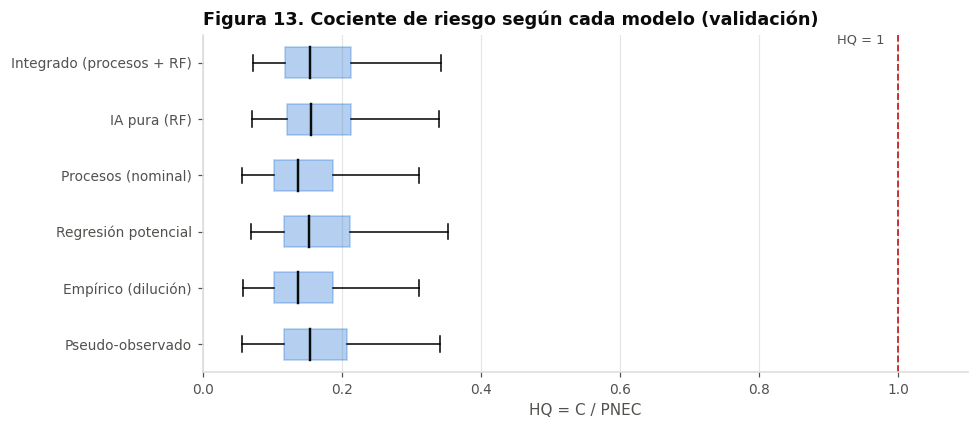

In [32]:
filas = []
for nom, v in {"Pseudo-observado": y_te, **PRED}.items():
    fila = {"Modelo": nom, "HQ máx.": v.max()/PNEC, "% muestras HQ ≥ 1": 100*np.mean(v/PNEC >= 1)}
    for e, p in ESPECIES.items():
        corto = e.split(" ")[0]
        fila[f"UT máx. {corto}"] = v.max()/p["CL50"]
        fila[f"M máx. {corto}"] = float(mortalidad_loglogistica(v.max(), p["CL50"], p["b"]))
    filas.append(fila)
df_riesgo = pd.DataFrame(filas)
tabla(df_riesgo, "t24_riesgo_por_modelo", "Tabla 24. Riesgo ecológico estimado por cada modelo (validación)", precision=5)

fig, ax = plt.subplots(figsize=(9, 4))
datos = [y_te/PNEC] + [v/PNEC for v in PRED.values()]
nombres = ["Pseudo-observado"] + list(PRED.keys())
bp = ax.boxplot(datos, vert=False, widths=0.55, patch_artist=True, showfliers=False,
                medianprops=dict(color=COL["ink"], lw=1.6))
for patch in bp["boxes"]:
    patch.set(facecolor=COL["s1"], alpha=0.35, edgecolor=COL["s1"])
ax.set_yticks(range(1, len(nombres) + 1)); ax.set_yticklabels(nombres)
ax.axvline(1, color=COL["crit"], lw=1.2, ls="--")
ax.text(0.98, len(nombres) + 0.35, "HQ = 1", ha="right", fontsize=8.5, color=COL["ink2"])
ax.set_xlim(0, 1.1); ax.set_xlabel("HQ = C / PNEC"); ax.grid(axis="y", visible=False)
ax.set_title("Figura 13. Cociente de riesgo según cada modelo (validación)")
fig.tight_layout(); guardar(fig, "fig13_riesgo_modelos"); plt.show()

---
# 8. Resumen de resultados y exportación

In [33]:
# ============================================================================
# 8. RESUMEN
# ============================================================================
df_val = pd.DataFrame([{"Clave": k, "Valor": v[0], "Unidad": v[1], "Descripción": v[2]} for k, v in VALORES.items()])
tabla(df_val, "t00_valores_clave", "Tabla resumen. Valores clave de la simulación", precision=6)

met = df_met.set_index("Modelo")
rank = met.drop(index="Techo: realidad sin error analítico")["NSE"].sort_values(ascending=False)
bio_p = df_bio[df_bio["Escenario"] == "Perturbado"]
bio_s = df_bio[df_bio["Escenario"] == "Estrés (100×W)"]

texto = f"""
### Conclusiones automáticas

1. **Ingreso y mezcla.** Con 0.005–0.011 mg/L en el efluente la carga es {VALORES['W_min'][0]:,.0f}–{VALORES['W_max'][0]:,.0f} g/d y la
   concentración de mezcla 0.00056–0.00122 mg/L. El modelo empírico reproduce el documento
   (C₀ = {C0_emp:.5f} mg/L, HQ = {HQ0:.2f}, HQ máx. = {HQmx:.2f}).
2. **Hidráulica.** Con Manning el tramo tiene h = {HB['h']:.2f} m, u = {HB['u']:.2f} m/s y TRH = {HB['TRH_h']:.2f} h;
   D_L (Fischer) = {HB['DL']:.0f} m²/s.
3. **Destino.** k total ≈ {KB['k_total']:.3f} 1/d; en el tramo se pierde apenas
   {100 - VALORES['frac_exportada'][0]:.2f} % de la carga y el {VALORES['frac_exportada'][0]:.2f} % sale aguas abajo: **la advección domina**.
   La volatilización y la sorción son despreciables; la fugacidad nivel III ubica {VALORES['fug_agua'][0]:.2f} % del PAP en el agua.
4. **Procesos (365 d, horario).** C media en Uchumayo = {C_uch.mean()*1000:.3f} µg/L, máximo horario = {C_uch.max()*1000:.3f} µg/L;
   el promedio diario subestima el pico en {df_proc.iloc[4]['Valor']:.1f} %, lo que justifica el paso horario.
   HQ máximo = {C_pert.max()/PNEC:.2f} < 1.
5. **Biota.** Entre Control y Perturbado el cambio de biomasa media es
   {', '.join(f"{r['Especie']} {r['Cambio medio vs Control (%)']:+.4f} %" for _, r in bio_p.iterrows())}.
   En la prueba de estrés (100×W): {', '.join(f"{r['Especie']} {r['Cambio medio vs Control (%)']:+.2f} %" for _, r in bio_s.iterrows())},
   lo que confirma que el acople tóxico–biota responde cuando la exposición se acerca a las CE50.
6. **Modelo integrado.** En validación: procesos NSE = {met.loc['Procesos (nominal)', 'NSE']:.3f},
   IA pura NSE = {met.loc['IA pura (RF)', 'NSE']:.3f}, integrado NSE = {met.loc['Integrado (procesos + RF)', 'NSE']:.3f}
   (RMSE {met.loc['Procesos (nominal)', 'RMSE (mg/L)']*1000:.4f} → {met.loc['Integrado (procesos + RF)', 'RMSE (mg/L)']*1000:.4f} µg/L).
   Orden por NSE: {' > '.join(f"{k} ({v:.3f})" for k, v in rank.items())}; techo alcanzable = {met.loc['Techo: realidad sin error analítico', 'NSE']:.3f}.
   El integrado corrige el sesgo del modelo de procesos (sesgo {met.loc['Procesos (nominal)', 'Sesgo medio (mg/L)']*1000:+.4f} → {met.loc['Integrado (procesos + RF)', 'Sesgo medio (mg/L)']*1000:+.4f} µg/L)
   y supera tanto a los procesos solos como a la IA pura. La cobertura calibrada del intervalo P5–P95 es {cobertura:.1f} %.
7. **Riesgo.** Todos los modelos (empírico, procesos, IA e integrado) coinciden en HQ < 1 para las tres especies:
   la dilución del Chili en estiaje basta para el rango de carga planteado. La carga crítica que haría HQ = 1 en
   estiaje es ≈ {W_crit:,.0f} g/d. Esto no implica que el PAP sea inocuo (mayor sensibilidad de estadios embrionarios).

**Limitación principal:** no hay mediciones de PAP en el Chili; las métricas del integrado miden la capacidad de la IA
para corregir procesos no representados en un experimento sintético, no una validación con datos de campo.
"""
display(Markdown(texto))

with open(RES_DIR/"RESUMEN_RESULTADOS.md", "w", encoding="utf-8") as fh:
    fh.write("# Resumen de resultados — PAP en el río Chili\n")
    fh.write(texto)
    fh.write("\n## Tablas exportadas\n\n")
    for n_, (tit, _) in TABLAS.items():
        fh.write(f"- `{n_}.csv` — {tit}\n")
    fh.write("\n## Figuras\n\n")
    for n_, ruta in FIGURAS.items():
        fh.write(f"- `{ruta}`\n")
print(f"{len(TABLAS)} tablas y {len(FIGURAS)} figuras exportadas en {OUT_DIR.resolve()}")

**Tabla resumen. Valores clave de la simulación**  ·  `tif_pap/resultados/t00_valores_clave.csv`

Clave,Valor,Unidad,Descripción
W_min,648.000000,g/d,Carga mínima
W_max,1425.600000,g/d,Carga máxima
hid_h,0.614555,m,Hidráulica base: h
hid_u,1.098355,m/s,Hidráulica base: u
hid_DL,55.620166,m²/s,Hidráulica base: DL
hid_TRH_h,2.529034,h,Hidráulica base: TRH_h
k_total,0.080475,1/d,k total nominal (15 °C)
fug_agua,99.866934,%,Fracción del PAP en agua (nivel III)
PNEC,0.003600,mg/L,PNEC = 0.036/10
C0_emp,0.000857,mg/L,C0 empírico (W=1000 g/d)



### Conclusiones automáticas

1. **Ingreso y mezcla.** Con 0.005–0.011 mg/L en el efluente la carga es 648–1,426 g/d y la
   concentración de mezcla 0.00056–0.00122 mg/L. El modelo empírico reproduce el documento
   (C₀ = 0.00086 mg/L, HQ = 0.24, HQ máx. = 0.34).
2. **Hidráulica.** Con Manning el tramo tiene h = 0.61 m, u = 1.10 m/s y TRH = 2.53 h;
   D_L (Fischer) = 56 m²/s.
3. **Destino.** k total ≈ 0.080 1/d; en el tramo se pierde apenas
   0.84 % de la carga y el 99.16 % sale aguas abajo: **la advección domina**.
   La volatilización y la sorción son despreciables; la fugacidad nivel III ubica 99.87 % del PAP en el agua.
4. **Procesos (365 d, horario).** C media en Uchumayo = 0.756 µg/L, máximo horario = 1.074 µg/L;
   el promedio diario subestima el pico en 21.1 %, lo que justifica el paso horario.
   HQ máximo = 0.30 < 1.
5. **Biota.** Entre Control y Perturbado el cambio de biomasa media es
   Fitoplancton -0.0001 %, Daphnia +0.0000 %, Trucha -0.0026 %.
   En la prueba de estrés (100×W): Fitoplancton -0.81 %, Daphnia -1.80 %, Trucha -10.33 %,
   lo que confirma que el acople tóxico–biota responde cuando la exposición se acerca a las CE50.
6. **Modelo integrado.** En validación: procesos NSE = 0.840,
   IA pura NSE = 0.920, integrado NSE = 0.928
   (RMSE 0.0991 → 0.0666 µg/L).
   Orden por NSE: Regresión potencial (0.928) > Integrado (procesos + RF) (0.928) > IA pura (RF) (0.920) > Procesos (nominal) (0.840) > Empírico (dilución) (0.836); techo alcanzable = 0.947.
   El integrado corrige el sesgo del modelo de procesos (sesgo -0.0705 → -0.0014 µg/L)
   y supera tanto a los procesos solos como a la IA pura. La cobertura calibrada del intervalo P5–P95 es 87.2 %.
7. **Riesgo.** Todos los modelos (empírico, procesos, IA e integrado) coinciden en HQ < 1 para las tres especies:
   la dilución del Chili en estiaje basta para el rango de carga planteado. La carga crítica que haría HQ = 1 en
   estiaje es ≈ 4,199 g/d. Esto no implica que el PAP sea inocuo (mayor sensibilidad de estadios embrionarios).

**Limitación principal:** no hay mediciones de PAP en el Chili; las métricas del integrado miden la capacidad de la IA
para corregir procesos no representados en un experimento sintético, no una validación con datos de campo.


25 tablas y 13 figuras exportadas en /home/jeremy/Documentos/modelamiento/tif_pap


---
## Referencias

- Bangia, S., Bangia, R., y Daverey, A. (2023). Pharmaceutically active compounds in aqueous environment: recent developments in their fate, occurrence and elimination for efficient water purification. *Environmental Monitoring and Assessment, 195*, 1344. https://doi.org/10.1007/s10661-023-11858-7
- Bavumiragira, J. P., Ge, J., y Yin, H. (2022). Fate and transport of pharmaceuticals in water systems: A processes review. *Science of The Total Environment, 823*, 153635. https://doi.org/10.1016/j.scitotenv.2022.153635
- Davoudi, M., Koushafar, A., Karimi Organi, F., Fathian, H., y Maboudi, H. (2025). Environmental fate of nutrients in the Karun River using the AQUATOX model. *Journal of Advances in Environmental Health Research, 13*(3), 207–217. https://doi.org/10.34172/jaehr.1412
- Dodig, A., Ricci, E., Kvascev, G., y Stojkovic, M. (2024). A novel machine learning-based framework for the water quality parameters prediction using hybrid long short-term memory and locally weighted scatterplot smoothing methods. *Journal of Hydroinformatics, 26*(5), 1059–1079. https://doi.org/10.2166/hydro.2024.273
- Mengistu, T. D., Chung, I.-M., y Chang, S. W. (2026). Machine learning for water quality prediction and uncertainty assessment. *Physics and Chemistry of the Earth, Parts A/B/C, 143*, 104319. https://doi.org/10.1016/j.pce.2026.104319
- Yin, C.-F., Pan, P., Li, T., Song, X., Xu, Y., y Zhou, N.-Y. (2025). The universal accumulation of p-aminophenol during the microbial degradation of analgesic and antipyretic acetaminophen in WWTPs: A novel metagenomic perspective. *Microbiome, 13*(1), 68. https://doi.org/10.1186/s40168-025-02065-2
- Zhang, Y., Wang, J., Xu, J., et al. (2026). Stage-dependent developmental and reproductive toxicity of p-aminophenol in the freshwater snail *Biomphalaria glabrata*: Linking organ-level pathology to ecological hazard. *Aquatic Toxicology, 297*, 107866. https://doi.org/10.1016/j.aquatox.2026.107866